# Current version : 10.D (2025-07-23)

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import clear_output
from datetime import datetime
import pickle
from datetime import datetime
import math

pd.options.display.max_rows = 2000

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects


# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

today = datetime.today().strftime('%Y-%m-%d')

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=[ '#009736','#EE2A35',"#3f488aff",
                                                    "#f79a00ff", "#cf1100ff", "#81a5bfff",
                                                    "#f9bd00ff","#547200ff", "#bfd8cdff"]) 

In [2]:
import scanpy as sc

In [3]:
from module.misc import sample_name_import

name_dir = "circa-SD"

samples, samples_ids = sample_name_import(name_dir)

print(len(samples))
print(samples)

12
['circa4-IGM-ZT01', 'circa4-IGM-ZT05', 'circa4-IGM-ZT09', 'circa4-IGM-ZT13', 'circa4-IGM-ZT17', 'circa4-IGM-ZT21', 'SD1-ZT01', 'SD1-ZT05', 'SD1-ZT09', 'SD1-ZT13', 'SD1-ZT17', 'SD1-ZT21']


In [4]:
# dir_notebook = '../notebook'
dir_notebook = 'D:\Jupyter_notebook\Xenium_jupyter_notebook'
name_dir = 'circa-SD'

In [5]:
df = pd.read_parquet(f'{dir_notebook}/csv/circa-SD/circa-SD_norm_combined.parquet')

In [37]:
df.groupby(['cell_type_final'])['Ruvbl1'].mean().sort_values()
# plt.scatter(df['Ruvbl1'], df["Ruvbl2"])

cell_type_final
Endothelial              0.059729
Pericyte                 0.059819
SMC                      0.061676
Astro TE                 0.063656
Oligodendrocyte          0.066242
L6 IT CTX Glut           0.070125
VP Glut                  0.071334
Microglia                0.073792
AV Glut                  0.074065
AD Glut                  0.076534
OPC                      0.077781
TRS BAC Glut             0.078023
MH Glut                  0.078516
SMT Glut                 0.080333
VLMC                     0.081276
RT ZI Gaba               0.083667
CM Glut                  0.084679
VM MD Glut               0.086796
DG Glut                  0.089247
L6b CTX Glut             0.089683
ABC                      0.089958
SCH Gaba                 0.091429
Vip Gaba                 0.091920
LD Glut                  0.092021
RE Glut                  0.095873
L2 3 IT RSP Glut         0.095896
Lamp5 Gaba               0.096469
STR Gaba                 0.097032
Choroid                  0.09866

In [39]:
ddf = df[df['Ruvbl1']!=0].groupby('cell_type_final')['Ruvbl1'].count() / df.groupby('cell_type_final')['Ruvbl1'].count()
ddf.sort_values()

cell_type_final
SMC                      0.059919
Endothelial              0.065389
Pericyte                 0.069096
Oligodendrocyte          0.087372
Microglia                0.093816
Astro TE                 0.101177
VLMC                     0.113515
L6 IT CTX Glut           0.121696
OPC                      0.122247
TRS BAC Glut             0.125685
MH Glut                  0.132838
ABC                      0.135432
DG Glut                  0.145131
SCH Gaba                 0.151447
L2 3 IT RSP Glut         0.155218
AD Glut                  0.155963
BAC Glut                 0.159190
Tanycyte                 0.162413
Vip Gaba                 0.166124
VP Glut                  0.175395
STR D2 Gaba              0.175890
AV Glut                  0.176867
Choroid                  0.181521
Lamp5 Gaba               0.182484
RT ZI Gaba               0.183929
L5 NP CTX Glut           0.196204
STR PAL Gaba             0.197895
OB STR CTX IMN           0.198231
STR Gaba                 0.19877

In [ ]:
df[df['cell_type_final']=="Microglia"].groupby(['run','region_automap_name'])['cell_type_final'].value_counts().to_csv('data/microglia_dsitrib.csv')

In [ ]:
df.groupby('cell_type_final')['Bdnf'].mean().sort_values()

# List of lists

In [54]:
### Extract common phase
cell_list_under = ['SMC', 'Sncg_Gaba', 'STR_Gaba', 'COAa_PAA_MEA_Glut', 'OB_STR_CTX_IMN', 'MEA_Glut', 'L5_NP_CTX_Glut',
              'PAL_STR_Gaba_Chol', 'Vip_Gaba', 'Lamp5_Gaba', 'CLA_EPd_CTX_Glut', 'STR_PAL_Gaba', 'L6b_CTX_Glut',
                'Sst_Gaba', 'VLMC', 'PVH_Glut', 'ABC', 'AHN_Glut', 'SCH_Gaba', 'L5_ET_CTX_Glut', 'Choroid', 'Pericyte',
                  'LHA_Glut', 'Pvalb_Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2_3_IT_PIR_ENTl_Glut', 'L6_CT_CTX_Glut',
              'Endothelial', 'STR_D1_Gaba', 'L4_5_IT_CTX_Glut', 'Oligodendrocyte', 'STR_D2_Gaba', 'L6_IT_CTX_Glut', 'Astro_TE']
len(cell_list_under)

36

# Cell Population

In [9]:
grouped = df.groupby(['run','sample','region_automap_name'])['cell_type_final'].value_counts(dropna=True)
grouped.to_csv('data/cell_count_region.csv')

In [ ]:
import math
df = pd.read_csv('data/cell_count_region.csv')

df = df[df['count'] > 10]

df_nbcells_av = []
df_nbcells_sem = []
df_nbcells_pct = []

all_regions = df['region_automap_name'].unique()
all_celltypes = df['cell_type_final'].unique()

for region in all_regions:
    dat_av = pd.DataFrame()
    dat_sem = pd.DataFrame()
    dat_pct = pd.DataFrame()
    
    for cell in all_celltypes:
        temp_av = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].mean()
        tempdf = pd.DataFrame(data = {cell : temp_av})
        dat_av = pd.concat([dat_av, tempdf], axis=1)

        temp_percent = df[(df['cell_type_final']== cell)& (df['region_automap_name'] == region) ].groupby('run')['count'].sum() / df[df['region_automap_name'] == region].groupby('run')['count'].sum() * 100
        tempdf = pd.DataFrame(data = {cell : temp_percent}) 
        dat_pct = pd.concat([dat_pct, tempdf], axis=1)  

        temp_sem = df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].std() / df[(df['cell_type_final']== cell) & (df['region_automap_name'] == region)].groupby('run')['count'].count()
        tempdf = pd.DataFrame(data = {cell : temp_sem})
        dat_sem = pd.concat([dat_sem, tempdf], axis=1)
    
    df_nbcells_sem.append(dat_sem)
    df_nbcells_av.append(dat_av)
    df_nbcells_pct.append(dat_pct)

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_av[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_sem[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

writer = pd.ExcelWriter(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', engine='xlsxwriter')
for j in range(0,len(all_regions)):
    df_nbcells_pct[j].to_excel(writer, sheet_name=all_regions[j], index=False)
writer.close()

In [10]:
df_average = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_average.xlsx', sheet_name=None)
df_std = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_std.xlsx', sheet_name=None)
df_pct = pd.read_excel(f'{dir_notebook}/analysis/{name_dir}/celltype_pct.xlsx', sheet_name=None)

df_average = {key: value for key, value in sorted(df_average.items())}
df_std = {key: value for key, value in sorted(df_std.items())}
df_pct = {key: value for key, value in sorted(df_pct.items())}


df_average.pop('VLMC')
df_average.pop('Ependymal')
df_average.pop('Choroid')
df_average.pop('Tanycyte')

df_std.pop('Tanycyte')
df_std.pop('VLMC')
df_std.pop('Choroid')
df_std.pop('Ependymal')

df_pct.pop('Tanycyte')
df_pct.pop('VLMC')
df_pct.pop('Choroid')
df_pct.pop('Ependymal')
df_pct.pop('AD')

,Astro TE,AHN Glut,Oligodendrocyte,Endothelial,OPC,PVH Glut,Microglia,Pericyte,LHA Glut,CEA Gaba,...,MH Glut,CA3 Glut,CA1 ProS Glut,LD Glut,LH Glut,RT ZI Gaba,VP Glut,AD Glut,PT Glut,Tanycyte
0,24.441133,NaN,18.554396,10.134128,1.266766,NaN,1.266766,1.788376,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.579732,NaN,NaN


In [18]:
df_pct['SCH'].sum(axis=0)

Astro TE                  69.151654
AHN Glut                   0.619971
Oligodendrocyte            8.291257
Endothelial                7.664049
OPC                        2.673970
PVH Glut                   0.000000
Microglia                  1.583986
Pericyte                   1.162398
LHA Glut                   0.276849
CEA Gaba                   0.000000
MEA Glut                   0.000000
COAa PAA MEA Glut          0.000000
STR PAL Gaba               0.000000
L2 3 IT PIR ENTl Glut      0.000000
Vip Gaba                   0.000000
L6 IT CTX Glut             0.000000
L4 5 IT CTX Glut           0.000000
L6 CT CTX Glut             0.000000
Pvalb Gaba                 0.000000
Sst Gaba                   0.000000
L6b CTX Glut               0.000000
L5 ET CTX Glut             0.000000
Lamp5 Gaba                 0.000000
ABC                        0.000000
CLA EPd CTX Glut           0.000000
L5 NP CTX Glut             0.000000
VLMC                       0.207636
Sncg Gaba                  0

In [ ]:
df_pct['SCH']['OPC']

,Astro TE,AHN Glut,Oligodendrocyte,Endothelial,OPC,PVH Glut,Microglia,Pericyte,LHA Glut,CEA Gaba,...,MH Glut,CA3 Glut,CA1 ProS Glut,LD Glut,LH Glut,RT ZI Gaba,VP Glut,AD Glut,PT Glut,Tanycyte
0,34.640674,0.265313,3.898950,3.449071,1.11893,NaN,0.738263,0.357596,0.276849,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,34.510981,0.354658,4.392307,4.214977,1.55504,NaN,0.845724,0.804802,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
for key in df_average.keys():
    df_average[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_average[key].columns]
    df_average[key].index = ['NS','SD']
    df_std[key].index = ['NS','SD']

    plt.figure(figsize=(5,8))
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T['NS'],
           height= 0.45, align='edge', label = 'NS',edgecolor='black',
           xerr= df_std[key].T['NS'] 
           )
    plt.barh(y=df_average[key].T.index,
         width=df_average[key].T['SD'],
           height= -0.45, align='edge', label = 'SD',edgecolor='black',
           xerr= df_std[key].T['SD'] )
    plt.xlabel('Average cell number')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig('Gallery/circa-SD_cellnb.svg')
    clear_output()

In [ ]:
len(df_pct[key])

In [ ]:
for key in df_pct.keys():
    if len(df_pct[key]) == 1:
        continue
    df_pct[key] = df_pct[key][df_pct[key].select_dtypes(np.number).gt(0.5)]
    df_pct[key].dropna(axis=1, inplace = True)
    df_std[key] = df_std[key][df_pct[key].columns]
    df_pct[key].index = ['NS','SD']
    df_std[key].index = ['NS','SD']

    plt.figure(figsize=(5,8))
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['NS'],
           height= 0.45, align='edge', label = 'NS',edgecolor='black',
           )
    plt.barh(y=df_pct[key].T.index,
         width=df_pct[key].T['SD'],
           height= -0.45, align='edge', label = 'SD',edgecolor='black',
           )
    plt.xlabel('Percentage cells')
    plt.legend()
    plt.title(f'Average cell population : {key}')
    # plt.savefig('Gallery/circa-SD_cellnb.svg')
    clear_output()

# Expressed genes

In [ ]:
df_NS = df[(df['run']=='circa4')]
df_SD = df[(df['run']=='SD1')]
del df

In [ ]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k')
dict_pos = {}

gene_columns = df_SD[clock_genes]
grouped = df_SD.groupby('cell_type_final')


for cell_type, group in grouped:
    gene_presence_pct = group.iloc[:, :-1].mean()
    expressed_genes = gene_presence_pct[gene_presence_pct >= 0.01].index.tolist()
    dict_pos[cell_type] = expressed_genes


In [ ]:
gene_nb = [len(dict_pos[key]) for key in dict_pos.keys()]
gene_nb

In [ ]:
gene_nb.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

# Cycling genes

In [ ]:
import pandas as pd

In [ ]:
df_circa2 = pd.read_excel('../R/Results/2025-07-22_SD1_region/Summary/2025-07-22_SD1_cyc_siggene_analysis.xlsx', sheet_name = 'sig_cyl_gene')
df_circa4 = pd.read_excel('../R/Results/2025-07-22_circa4_region/Summary/2025-07-22_circa4_cyc_siggene_analysis.xlsx', sheet_name = 'sig_cyl_gene')

In [ ]:
circa4_gene = set(df_circa4['CycID'])
circa2_gene = set(df_circa2['CycID'])

In [ ]:
common_genes = circa4_gene.intersection(circa2_gene)

In [ ]:
len(common_genes), len(circa4_gene),len(circa2_gene)

In [ ]:
# library
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Use the venn2 function
venn2(subsets = (1449, 846, 560), set_labels = ('IGM', 'Salk'))
plt.show()


## Polar plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': ['Arntl', 'Clock', 'Cry1', 'Cry2','Npas2', 'Nr1d1', 'Per2', 'Per3','Rorc',
                            'Arntl','Clock','Cry1','Nr1d1','Per1','Per2','Per3','Rorc'
                            ],
                    'Phase': [1.00, 8.38, 15.31, 12.89, 22.56, 8.96,15.30,13.06,16.54,
                              1.00, 3.15, 16.75, 9.02, 11.92, 16.23, 14.17, 17.06
                            ]
                    })

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

ax.set_yticks(range(1, len(gene_order) + 1))
ax.set_yticklabels(gene_order)
ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left", title='Gene')

plt.tight_layout()
plt.show()

## Cell type spe polar

In [ ]:
import pandas as pd

dir_sum = '../R/Results/2025-06-25_circa4_celltype/Summary'

df = pd.read_excel(f'{dir_sum}/2025-06-25_circa4_cyc_siggene_by_celltype.xlsx', sheet_name=None, usecols=['CycID', 'meta2d_phase'])

In [ ]:
clockgenelist=['Arntl', 'Clock', 'Cry1', 'Cry2', 'Npas2', 'Nr1d1', 'Per1', 'Per2', 'Per3', 'Rora', 'Rorb', 'Rorc']
dataset = pd.DataFrame()
for key in df.keys():
    subdf = df[key].filter(['CycID', 'meta2d_phase'], axis=1)
    subdf = subdf[subdf['CycID'].isin(clockgenelist)]
    dataset = pd.concat([dataset, subdf])

In [ ]:
all_celltype_CG = dict(zip(dataset['CycID'], dataset['meta2d_phase']))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample structure: replace this with your real data
# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Each row = one observation of a gene at a specific phase
data = pd.DataFrame({
                    'Gene': dataset['CycID'],
                    'Phase': dataset['meta2d_phase']
                    })
data = data.sort_values('Gene')

# Convert phase to radians for polar plot
data['Radians'] = data['Phase'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data['Gene'].unique()
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data['Gene'].map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data['Gene'].map(gene_colors)

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data['Gene'] == gene]
    ax.scatter(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene], s=40)

# # for gene in gene_order:
# gene = 'Per1'
# subset = data[data['Gene'] == gene]
# ax.hist(subset['Radians'], subset['Radius'], label=gene, color=gene_colors[gene])  


# ax.set_yticks(range(1, len(gene_order) + 1))
# ax.set_yticklabels(gene_order)
# ax.set_ylim(0.5, len(gene_order) + 0.5)
ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

plt.title('Clock Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

## Histo polar plot

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
run_namdate_NS = "2025-08-08_circa4"
run_namdate_SD = "2025-08-09_SD1"
run_type = 'celltype'

dir_sum_NS = f'../R/Results/{run_namdate_NS}_{run_type}/Summary'
dir_sum_SD = f'../R/Results/{run_namdate_SD}_{run_type}/Summary'


df_all_NS = pd.read_excel(f'{dir_sum_NS}/{run_namdate_NS}_cyc_siggene_analysis.xlsx', sheet_name=None)
df_all_SD = pd.read_excel(f'{dir_sum_SD}/{run_namdate_SD}_cyc_siggene_analysis.xlsx', sheet_name=None)


# cycling_summary = pd.read_csv(f'{dir_sum}/{run_namdate}_cycling_gene_count_by_celltype.csv', index_col='cycling_gene_count')

In [ ]:
common_regions = set(df_all_NS.keys()).intersection(df_all_SD.keys())

for idx, celltype in enumerate(common_regions):
# for idx, celltype in enumerate(["Astro TE"]):
    # Data preparation
    df_NS = pd.DataFrame(data=zip(df_all_NS[celltype]['CycID'], df_all_NS[celltype]['meta2d_phase']))
    df_NS.columns = ['Gene','Phase']
    df_NS['Radians'] = df_NS['Phase'] / 24 * 2 * np.pi

    df_SD = pd.DataFrame(data=zip(df_all_SD[celltype]['CycID'], df_all_SD[celltype]['meta2d_phase']))
    df_SD.columns = ['Gene','Phase']
    df_SD['Radians'] = df_SD['Phase'] / 24 * 2 * np.pi

    # Plot
    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.set_theta_direction(-1)
    ax.set_theta_offset(np.pi / 2.0)
    ax.grid(True)

    ax.hist(df_NS['Radians'], bins = 24, alpha = 0.75, label = "NS")
    ax.hist(df_SD['Radians'], bins = 24, alpha = 0.75, label = "SD")

    ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
    ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])

    plt.title(f'Genes Phase in {celltype}')
    plt.legend()
    plt.savefig(f'Gallery/{today}/polarplot/polar_gene_{celltype}.svg')
    plt.show()
    plt.close()


### Histo polar in region/gene panel

In [ ]:
import pandas as pd
from module.misc import genes_list

gene_list = genes_list('mitochondria')
region = 'SCH'
df_all = pd.read_excel(f'../R/Results/2025-08-11_circa4_celltype_and_region/Summary/2025-08-11_circa4_cyc_siggene_analysis.xlsx', sheet_name=region)

# # Data preparation
# df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
# df.columns = ['Gene','Phase']
# df = df[df['Gene'].isin(gene_list)]
# df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# # Plot
# plt.figure(figsize=(6,6))
# ax = plt.subplot(111, polar=True)
# ax.set_theta_direction(-1)
# ax.set_theta_offset(np.pi / 2.0)
# ax.grid(True)

# ax.hist(df['Radians'], bins = 24,
#         #  color = 'green'
#          )

# ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
# ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

# plt.title(f'Genes Phase in {region}')
# # plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from module.misc import genes_list

region = 'SCH'
df_all = pd.read_excel(f'data/SCH_cyc_analysis.xlsx', sheet_name='sig_cyl_gene')
gene_list = genes_list('mitochondria')

# Data preparation
df = pd.DataFrame(data=zip(df_all['CycID'], df_all['meta2d_phase']))
df.columns = ['Gene','Phase']
df = df[df['Gene'].isin(gene_list)]
df['Radians'] = df['Phase'] / 24 * 2 * np.pi

# Plot
plt.figure(figsize=(6,6))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

ax.hist(df['Radians'], bins = 24,
        #  color = 'green'
         )

ax.set_xticks(np.linspace(0, 2 * np.pi, 12, endpoint=False))
ax.set_xticklabels(['0', '2', '4','6', '8', '10','12','14', '16','18', '20','22'])

plt.title(f'Genes Phase in {region}')
# plt.savefig(f'Gallery/circa2/polar_gene_{region}.svg')

## Phase comparison

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
run_namdate_1 = "2025-08-08_circa4"
run_namdate_2 = "2025-08-09_SD1"
run_type = 'celltype'
cell_type_plot = 'SCH Gaba'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

df_all_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)
df_all_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=cell_type_plot)

In [ ]:
from module.misc import genes_list

gene_list_plot = genes_list("clock")

dataset_NS = pd.DataFrame()

subdf_all_NS = df_all_NS.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_NS = subdf_all_NS[subdf_all_NS['CycID'].isin(gene_list_plot)]
dataset_NS = pd.concat([dataset_NS, subdf_all_NS])

dataset_SD = pd.DataFrame()
subdf_all_SD = df_all_SD.filter(['CycID', 'meta2d_phase'], axis=1)
subdf_all_SD = subdf_all_SD[subdf_all_SD['CycID'].isin(gene_list_plot)]
dataset_SD = pd.concat([dataset_SD, subdf_all_SD])

In [ ]:
data = pd.DataFrame(index=gene_list_plot)

In [ ]:
all_celltype_NS = dict(zip(dataset_NS['CycID'], dataset_NS['meta2d_phase']))
all_celltype_SD = dict(zip(dataset_SD['CycID'], dataset_SD['meta2d_phase']))

In [ ]:
data['NS'] = data.index.map(all_celltype_NS)
data['SD'] = data.index.map(all_celltype_SD)
# data.dropna(inplace= True)
data['Gene'] = data.index
data['Diff'] = data['NS'] - data['SD']
data = data.sort_values(by='NS')

In [ ]:

data['NS2'] = data['NS']
data['SD2'] = data['SD']

# for n in range(len(data)):
#     if data.iloc[n,data.columns.get_loc("Diff")] > 12:
#         if data.iloc[n,data.columns.get_loc("NS")] < data.iloc[n,data.columns.get_loc("SD")]:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")] + 24
#         else:
#             data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
#     else:
#         data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]
#         data.iloc[n,data.columns.get_loc("SD")] = data.iloc[n,data.columns.get_loc("SD")]
thres = 12

for n in range(len(data)):
    if (abs(data.iloc[n,data.columns.get_loc("Diff")]) >= thres):
        if (data.iloc[n,data.columns.get_loc("SD")] > data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]-24
        elif (data.iloc[n,data.columns.get_loc("SD")] < data.iloc[n,data.columns.get_loc("NS")]):
            data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")] + 24
    else:
        data.iloc[n,data.columns.get_loc("SD2")] = data.iloc[n,data.columns.get_loc("SD")]
        data.iloc[n,data.columns.get_loc("NS2")] = data.iloc[n,data.columns.get_loc("NS")]

# data = data.sort_values(by="Diff", ascending=False)
data = data.sort_index()

In [ ]:
data

In [ ]:
# Convert phase to radians for polar plot
data['Radians_NS'] = data['NS'] / 24 * 2 * np.pi
data['Radians_SD'] = data['SD'] / 24 * 2 * np.pi

# Assign each gene a numeric ID for radial position (distance from center)
gene_order = data.index
gene_to_radius = {gene: i for i, gene in enumerate(gene_order, start=1)}
data['Radius'] = data.index.map(gene_to_radius)

# Color palette
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

# Plot
plt.figure(figsize=(5,5))
ax = plt.subplot(111, polar=True)
ax.set_theta_direction(-1)
ax.set_theta_offset(np.pi / 2.0)
ax.grid(True)

# Scatter plot
for gene in gene_order:
    subset = data[data.index == gene]
    ax.scatter(subset['Radians_NS'], subset['Radius'], label=gene, color=gene_colors[gene], s=40, edgecolors='black')
    ax.scatter(subset['Radians_SD'], subset['Radius'], color=gene_colors[gene], alpha = 0.5, s=40)

ax.set_xticks(np.linspace(0, 2 * np.pi, 6, endpoint=False))
ax.set_xticklabels(['0', '4', '8', '12', '16', '20'])
ax.set_ylabel(ylabel=None)
plt.title('Genes Phase')
ax.legend(bbox_to_anchor=(1.1, 1.0), loc="upper left")


plt.tight_layout()
plt.show()

In [ ]:
# Color palette
import seaborn as sns
gene_order = data.index
palette = sns.color_palette("hls", len(gene_order))
gene_colors = dict(zip(gene_order, palette))
data['Color'] = data.index.map(gene_colors)

In [ ]:
# data = data[0:20]

In [ ]:
plt.figure(figsize=(3,4))
ax =ax = plt.subplot()

for n in range(len(data)):
    ax.hlines(y=n, xmin=data.iloc[n,data.columns.get_loc("NS2")], xmax=data.iloc[n,data.columns.get_loc("SD2")], linestyles='dashed', color = 'black')
    ax.scatter(x=data.iloc[n,data.columns.get_loc("NS2")],y=n,
               color = data.iloc[n,data.columns.get_loc("Color")],
                 edgecolors='black', label = data.index.values[n])
    ax.scatter(x=data.iloc[n,data.columns.get_loc("SD2")], y=n, color = data.iloc[n,data.columns.get_loc("Color")])
ax.set_xlim(0,24)
ax.set_ylim(-0.25, len(data)-0.75)
ax.set_xticks([0,4,8,12,16,20,24])
ax.set_xlabel('ZT')
ax.set_yticks(ticks = range(len(data)),labels = data['Gene'])
ax.vlines(x = [0,12,24], ymin=0, ymax=len(data), color = 'darkgrey', linestyles='dashed')
ax.invert_yaxis()
plt.tight_layout()

# plt.legend()

## Barplot

In [ ]:
df_gen_NS = pd.read_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv', index_col="Celltype")
df_gen_SD = pd.read_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv', index_col="Celltype")

In [ ]:
df_gen_NS.to_csv('../notebook/analysis/circa-SD/NS-genexpression-summary.csv')
df_gen_SD.to_csv('../notebook/analysis/circa-SD/SD-genexpression-summary.csv')

In [ ]:
run_namdate_1 = "2025-08-08_circa4"
run_namdate_2 = "2025-08-09_SD1"
run_type = 'celltype'

dir_sum_1 = f'../R/Results/{run_namdate_1}_{run_type}/Summary'
dir_sum_2 = f'../R/Results/{run_namdate_2}_{run_type}/Summary'

cycling_summary_1 = pd.read_csv(f'{dir_sum_1}/{run_namdate_1}_cycling_gene_per_group.csv', index_col='celltype')
cycling_summary_2 = pd.read_csv(f'{dir_sum_2}/{run_namdate_2}_cycling_gene_per_group.csv', index_col='celltype')

In [ ]:
NS_dict = dict(zip(cycling_summary_1.index,cycling_summary_1['cycling_gene_count']))
SD_dict = dict(zip(cycling_summary_2.index,cycling_summary_2['cycling_gene_count']))

df_gen_NS['Cycling_pval'] = df_gen_NS.index.map(NS_dict)
df_gen_SD['Cycling_pval'] = df_gen_SD.index.map(SD_dict)

In [ ]:
df_NS = pd.read_excel(f'{dir_sum_1}/{run_namdate_1}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])
df_SD = pd.read_excel(f'{dir_sum_2}/{run_namdate_2}_cyc_siggene_analysis.xlsx', sheet_name=None, usecols=['CycID','meta2d_BH.Q'])


common = {}
sum_com = {}
common_cells = set(df_NS.keys()).intersection(set(df_SD.keys()))

for key in common_cells:
    # df_NS[key] = df_NS[key][df_NS[key]['meta2d_BH.Q']>=0.05]
    # df_SD[key] = df_SD[key][df_SD[key]['meta2d_BH.Q']>=0.05]
    common[key] = df_NS[key][df_NS[key]['CycID'].isin(df_SD[key]['CycID'])]
    sum_com[key] = len(common[key])

sum_com_df = pd.DataFrame({'Gene': sum_com.keys(),
                    'Common': sum_com.values()})
sum_com_df.index = sum_com_df['Gene']

In [ ]:
sum_com_dict = dict(zip(sum_com_df['Gene'],sum_com_df['Common']))
df_gen_NS['Common_pval'] = df_gen_NS.index.map(sum_com_dict)
df_gen_SD['Common_pval'] = df_gen_SD.index.map(sum_com_dict)


In [ ]:
df_NS_BH_nb = [len(df_NS[key]) for key in df_NS.keys()]
ddf_NS_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_NS_BH_nb}, index = df_NS.keys())

df_SD_BH_nb = [len(df_SD[key]) for key in df_SD.keys()]
ddf_SD_BH_nb = pd.DataFrame(data ={'Expressed_genes':df_SD_BH_nb}, index = df_SD.keys())

# NS_BH_dict = dict(zip(ddf_NS_BH_nb.index, ddf_NS_BH_nb['Expressed_genes']))
# df_gen_NS['Cycling_BH'] = df_gen_NS.index.map(NS_BH_dict)

# SD_BH_dict = dict(zip(ddf_SD_BH_nb.index, ddf_SD_BH_nb['Expressed_genes']))
# df_gen_SD['Cycling_BH'] = df_gen_SD.index.map(SD_BH_dict)

In [ ]:
cycling_summary_1 = cycling_summary_1[cycling_summary_1.index.isin(cycling_summary_2.index)].sort_values(by='cycling_gene_count')
cycling_summary_2 = cycling_summary_2[cycling_summary_2.index.isin(cycling_summary_1.index)]

In [ ]:
len(cycling_summary_1), len(cycling_summary_2)

In [ ]:
df_gen_NS.sort_values(by='Common_pval',inplace=True)
df_gen_NS.drop('CEA Gaba',axis=0, inplace=True)
# df_gen_NS.dropna(axis=0, inplace= True)
# df_gen_SD.dropna(axis=0, inplace= True)

In [ ]:
len(df_gen_NS), len(df_gen_SD)

In [ ]:
which_has_more_CG = {}

for gene in df_gen_NS.index:
    if df_gen_NS['Cycling_pval'][gene] < df_gen_SD['Cycling_pval'][gene]:
        which_has_more_CG[gene] = 0
    else:
        which_has_more_CG[gene] = 1

which_has_more_CG.keys()


In [ ]:
fig, ax = plt.subplots(figsize = (5,8))
# ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Count'], label = 'Expressed', color = 'None', edgecolor ='black')
# ax.barh(y = df_gen_SD.index, width = df_gen_SD['Count'], color = 'None', edgecolor = 'black')

ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Cycling_pval'], edgecolor = 'black', label = 'Cycling NS', align = "center")
ax.barh(y = df_gen_SD.index, width= df_gen_SD['Cycling_pval'], edgecolor = 'black', label = 'Cycling SD', align = "center")
ax.barh(y = df_gen_NS.index, width=df_gen_NS['Common_pval'], label = 'Common', color = 'black', align = "center")
ax.barh(y = df_gen_SD.index, width=-df_gen_SD['Common_pval'], color = 'black', align = "center")
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS))
ax.set_xlim(-2000,2000)
ax.grid(axis="x")
ax.set_axisbelow(b=True)
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep')

for n, gene in enumerate(which_has_more_CG.keys()):
    if which_has_more_CG[gene] > 0:
        ax.text(x = -df_gen_NS['Cycling_pval'][gene]-75, y = n-0.5, s = '#', weight = 'bold', ha = "center")
    else:
        ax.text(x = df_gen_SD['Cycling_pval'][gene]+75, y = n-0.5, s = '#',weight = 'bold', ha = "center")


plt.savefig(f'Gallery/{today}/Cycling_genes_overview.svg', dpi=300, format ="svg", transparent = True)

In [ ]:
which_has_more_CG

In [ ]:
order_list =[
        "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC",
        "Ependymal", "OB STR CTX IMN","OPC","Astro TE", "SCH Gaba","PVH Glut","AHN Glut","PAL STR Gaba Chol","MEA Glut","LHA Glut",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","L2 3 PIR ENTl Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "DG Glut","STR PAL Gaba","STR D1 Gaba","STR D2 Gaba",]


cycling_summary_1_sort = cycling_summary_1.reindex(order_list)
cycling_summary_1_sort.dropna(axis=0, inplace=True)
cycling_summary_1_sort = cycling_summary_1_sort.reindex(sorted(cycling_summary_1_sort.columns), axis=1)
cycling_summary_1_sort.head(2)

In [ ]:
df_gen_NS_sort =df_gen_NS.reindex(order_list)
df_gen_SD_sort = df_gen_SD.reindex(order_list)
df_gen_NS_sort.dropna(axis=0, inplace= True)
df_gen_SD_sort.dropna(axis=0, inplace= True)
cycling_summary_2_sort = cycling_summary_2.reindex(order_list)
cycling_summary_2_sort.dropna(axis=0, inplace=True)

In [ ]:
len(df_gen_NS_sort),len(df_gen_SD_sort),len(cycling_summary_1_sort),len(cycling_summary_2_sort)

In [ ]:
fig, ax = plt.subplots(figsize = (5,8))
# ax.barh(y = df_gen_NS.index, width = -df_gen_NS['Count'], label = 'Expressed', color = 'None', edgecolor ='black')
# ax.barh(y = df_gen_SD.index, width = df_gen_SD['Count'], color = 'None', edgecolor = 'black')
ax.barh(y = df_gen_NS_sort.index, width = -df_gen_NS_sort['Cycling_pval'], edgecolor = 'black', label = 'Cycling NS')
ax.barh(y = df_gen_SD_sort.index, width= df_gen_SD_sort['Cycling_pval'], edgecolor = 'black', label = 'Cycling SD')
ax.barh(y = df_gen_NS_sort.index, width=df_gen_NS_sort['Common_pval'], label = 'Common', color = 'black')
ax.barh(y = df_gen_SD_sort.index, width=-df_gen_SD_sort['Common_pval'], color = 'black')
ax.vlines(x=0,ymin=-1,ymax=len(df_gen_NS_sort), color = "black")
ax.set_ylim(-0.5,len(df_gen_NS_sort))
ax.legend(loc='lower left')
ax.set_title('Cycling genes in normal and disrupted sleep')
plt.savefig(f'Gallery/{today}/Cycling_genes_overview_dendro.svg',dpi=300)

## Cycling genes correlation

In [ ]:
run_namdate = "2025-07-21_circa4"
run_type = 'celltype'

dir_sum = f'../R/Results/{run_namdate}_{run_type}/Summary'

df_all = pd.read_excel(f'{dir_sum}/{run_namdate}_cyc_siggene_analysis.xlsx', sheet_name=None)

In [ ]:
from module.misc import genes_list

gens = genes_list('panel_5k')

df_genes = pd.DataFrame(data={"Gene" : gens}, index= gens)


for key in df_all.keys():
    df_genes[key] = np.zeros(len(df_genes))

    for gene in df_all[key]['CycID'].unique():
        df_genes.loc[gene,key] +=1



In [ ]:
df_genes.drop('Gene',axis=1, inplace=True)

In [ ]:
# order_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'PAL STR Gaba Chol',
#        'L2 3 PIR ENTl Glut', 'MEA Glut', 'OB STR CTX IMN', 'L5 NP CTX Glut',
#        'COAa PAA MEA Glut', 'Vip Gaba', 'Lamp5 Gaba', 'DG Glut', 'ABC',
#        'STR PAL Gaba', 'PVH Glut', 'L6b CTX Glut', 'AHN Glut', 'SCH Gaba',
#        'Sst Gaba', 'VLMC', 'L5 ET CTX Glut', 'Pericyte', 'LHA Glut',
#        'Ependymal', 'Pvalb Gaba', 'Microglia', 'OPC', 'L2 3 IT PIR ENTl Glut',
#        'STR D1 Gaba', 'L6 CT CTX Glut', 'Endothelial', 'Oligodendrocyte',
#        'L4 5 IT CTX Glut', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

order_list =[
        "Oligodendrocyte","Microglia","Endothelial","SMC","Pericyte","VLMC","ABC",
        "Ependymal", "OB STR CTX IMN","OPC","Astro TE", "SCH Gaba","PVH Glut","AHN Glut","PAL STR Gaba Chol","MEA Glut","LHA Glut",
    "Pvalb Gaba","STR Gaba","Sst Gaba","Sncg Gaba","Vip Gaba","Lamp5 Gaba","L6 IT CTX Glut","L4 5 IT CTX Glut","L5 ET CTX Glut",
    "L5 NP CTX Glut","L6b CTX Glut","L6 CT CTX Glut","L2 3 PIR ENTl Glut","L2 3 IT PIR ENTl Glut","COAa PAA MEA Glut",
    "DG Glut","STR PAL Gaba","STR D1 Gaba","STR D2 Gaba",]

df_genes_sort = df_genes.loc[:, order_list]

In [ ]:
df_corr = df_genes_sort.corr(method='kendall')

In [ ]:
df_corr.min().min()

In [ ]:
import seaborn as sns

sns.clustermap(df_corr, cmap = 'Blues', vmin=0,vmax=1,
                col_cluster=False,row_cluster=False, cbar = False, cbar_pos=None,figsize=(12, 12),
                )
plt.title('Correlation of cycling genes in NS')
plt.savefig(f'Gallery/{today}/NS_corr_cyclinggenes_ordernbcycgenes.svg',dpi=300)

## Phase Comparison plotting

### Summary table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from module.misc import genes_list
import numpy as np
import math

cg_list = genes_list('clock')

In [ ]:
dataframe_cg_cycling = pd.DataFrame(data = {"Gene" : cg_list,
                                            "Expressed": np.zeros(len(cg_list)),
                                            "NS_Cyc" : np.zeros(len(cg_list)),
                                            "SD_Cyc" : np.zeros(len(cg_list)),
                                            "Common_Cyc" : np.zeros(len(cg_list)),
                                            "Same_phase" : np.zeros(len(cg_list)),
                                            "Same Amplitude" :np.zeros(len(cg_list)),
                                            "Same Mesor" : np.zeros(len(cg_list))
                                             },
                                              index = cg_list)
dataframe_cg_cycling.sample()

In [7]:
cell_list = ['SMC', 'Sncg Gaba', 'STR Gaba', 'COAa PAA MEA Glut', 'OB STR CTX IMN', 'MEA Glut', 'L5 NP CTX Glut',
              'PAL STR Gaba Chol', 'Vip Gaba', 'Lamp5 Gaba', 'CLA EPd CTX Glut', 'STR PAL Gaba', 'L6b CTX Glut',
                'Sst Gaba', 'VLMC', 'PVH Glut', 'ABC', 'AHN Glut', 'SCH Gaba', 'L5 ET CTX Glut', 'Choroid', 'Pericyte',
                  'LHA Glut', 'Pvalb Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2 3 IT PIR ENTl Glut', 'L6 CT CTX Glut',
              'Endothelial', 'STR D1 Gaba', 'L4 5 IT CTX Glut', 'Oligodendrocyte', 'STR D2 Gaba', 'L6 IT CTX Glut', 'Astro TE']

In [ ]:
### Extract expression
for cell in cell_list:
    df_expressed_NS = pd.read_csv(f'../R/data/gene_list_SD1/{cell}.csv')
    gene_exp_NS = set(df_expressed_NS[df_expressed_NS['0'].isin(cg_list)]['0'])
    df_expressed_SD = pd.read_csv(f'../R/data/gene_list_circa4/{cell}.csv')
    gene_exp_SD = set(df_expressed_SD[df_expressed_SD['0'].isin(cg_list)]['0'])
    common_exp =  gene_exp_NS.intersection(gene_exp_SD)

    if len(common_exp) > 0:
        for gene in common_exp:
            dataframe_cg_cycling.loc[gene, "Expressed"] +=1

In [ ]:
### Extract common cycling

df_cycling_NS = pd.read_excel(f'../R/Results/2025-08-08_circa4_celltype/Summary/2025-08-08_circa4_cyc_siggene_analysis.xlsx', sheet_name = None)
df_cycling_SD = pd.read_excel(f'../R/Results/2025-08-09_SD1_celltype/Summary/2025-08-09_SD1_cyc_siggene_analysis.xlsx', sheet_name = None)

for cell in cell_list:
    gene_cyc_NS = set(df_cycling_NS[cell][df_cycling_NS[cell]['CycID'].isin(cg_list)]['CycID'])
    if len(gene_cyc_NS) > 0:
        for gene in gene_cyc_NS:
            dataframe_cg_cycling.loc[gene, "NS_Cyc"] +=1
    gene_cyc_SD = set(df_cycling_SD[cell][df_cycling_SD[cell]['CycID'].isin(cg_list)]['CycID'])
    if len(gene_cyc_SD) > 0:
        for gene in gene_cyc_SD:
            dataframe_cg_cycling.loc[gene, "SD_Cyc"] +=1
    common_cyc = gene_cyc_NS.intersection(gene_cyc_SD)
    if len(common_cyc) > 0:
        for gene in common_cyc:
            dataframe_cg_cycling.loc[gene, "Common_Cyc"] +=1

In [5]:
### Extract common phase
cell_list_under = ['SMC', 'Sncg_Gaba', 'STR_Gaba', 'COAa_PAA_MEA_Glut', 'OB_STR_CTX_IMN', 'MEA_Glut', 'L5_NP_CTX_Glut',
              'PAL_STR_Gaba_Chol', 'Vip_Gaba', 'Lamp5_Gaba', 'CLA_EPd_CTX_Glut', 'STR_PAL_Gaba', 'L6b_CTX_Glut',
                'Sst_Gaba', 'VLMC', 'PVH_Glut', 'ABC', 'AHN_Glut', 'SCH_Gaba', 'L5_ET_CTX_Glut', 'Choroid', 'Pericyte',
                  'LHA_Glut', 'Pvalb_Gaba', 'Ependymal', 'OPC', 'Microglia', 'L2_3_IT_PIR_ENTl_Glut', 'L6_CT_CTX_Glut',
              'Endothelial', 'STR_D1_Gaba', 'L4_5_IT_CTX_Glut', 'Oligodendrocyte', 'STR_D2_Gaba', 'L6_IT_CTX_Glut', 'Astro_TE']
len(cell_list_under)

36

In [ ]:
for cell in cell_list_under:
    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for difference in phase'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same_phase"] +=1

    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for amplitude difference'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same Amplitude"] +=1

    df_phase_NS = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    common_phase = set(df_phase_NS[(df_phase_NS['gene'].isin(cg_list)) & (df_phase_NS['P-value for mesor difference'] > 0.05)]['gene'])
    if len(common_phase) > 0:
            for gene in common_phase:
                dataframe_cg_cycling.loc[gene, "Same Mesor"] +=1

In [ ]:
dataframe_cg_cycling.sort_values(by='Common_Cyc')

In [ ]:
dataframe_cg_cycling.sort_values(by='Same_phase',inplace=True, ascending=False)

In [ ]:
w1 = dataframe_cg_cycling['Expressed'][0:25] - dataframe_cg_cycling['Common_Cyc'][0:25] 
w2 = dataframe_cg_cycling['Common_Cyc'][0:25] -  dataframe_cg_cycling["Same_phase"][0:25]
w3 = dataframe_cg_cycling["Same_phase"][0:25]

_, ax = plt.subplots(1,2, figsize = (4,6), sharey= True)

ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w1, left = 0, label = "Expressed NS/SD", color = "#3f488aff", edgecolor ="black")
ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w2, left = w1, label = "Cycling NS/SD", color= "#f79a00ff", edgecolor ="black")
ax[1].barh(y = dataframe_cg_cycling.index[0:25], width=w3, left = w1+w2, label = "In phase", color = "#81a5bfff", edgecolor ="black")
ax[1].set_xticks(ticks = [0,12,24,36])
ax[1].set_xlim(0,36)
ax[1].set_xlabel('Number of celltypes')
ax[1].legend(loc = 'best', bbox_to_anchor = (0.99,0.5))
                                          

ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['NS_Cyc'][0:25], height=0.4, align="edge", edgecolor ="black",label = "Cycling NS")
ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['SD_Cyc'][0:25], height=-0.4, align="edge", edgecolor ="black", label = "Cycling SD")
ax[0].barh(y=dataframe_cg_cycling.index[0:25], width = dataframe_cg_cycling['Expressed'][0:25], height=-0.8, align="center",fill = None, edgecolor ="black", label = "Expressed")

ax[0].legend(loc = 'upper left', bbox_to_anchor = (2.2,1))
ax[0].set_xticks(ticks = [0,12,24,36])
ax[0].set_xlim(0,36)
ax[0].set_xlabel('Number of celltypes')

plt.ylim(-0.5,24.5)

# plt.savefig(f"Gallery/{today}/Summary_cycling_phase_compare_top-inphase.svg", format='svg',transparent = True)

### Create database

In [8]:
dict_all_cycling = {}

for idx, cell in enumerate(cell_list_under):
    df_cyc_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
    df_cyc_NS.index = df_cyc_NS['CycID']
    df_cyc_filter_NS = pd.read_excel(f"../R/Results/2025-08-08_circa4_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
    df_cyc_filter_NS.index = df_cyc_filter_NS['CycID']
    df_cyc_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="meta")
    df_cyc_SD.index = df_cyc_SD['CycID']
    df_cyc_filter_SD = pd.read_excel(f"../R/Results/2025-08-09_SD1_celltype/Raw/{cell}_cyc_analysis.xlsx", sheet_name="sig_cyl_gene")
    df_cyc_filter_SD.index = df_cyc_filter_SD['CycID']
    df_circacompare = pd.read_csv(f'../R/Results/CircaCompare_Results/{cell}_circacompare_results.csv')
    df_circacompare.index = df_circacompare['gene']

    df_DEG = pd.read_excel('../notebook/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=cell_list[idx])
    df_DEG.index = df_DEG['names']
    # df_DEG = df_DEG[df_DEG['group'] == "SD1"]

    df_DEG_filter = df_DEG[(df_DEG['pvals_adj'] < 0.05)
                                 & (df_DEG['pct_nz_group'] > 0.0)
                                 & (df_DEG['pct_nz_reference'] > 0)
                                 & (abs(df_DEG['logfoldchanges']) > 0.26)
                                 & (df_DEG['mean_count'] >= 0.01)
                                 & (df_DEG['group'] == "SD1")
                                 ]


    dict_all_cycling[cell] = {"NS_cyc" : df_cyc_NS,
                              "NS_cyc_filter" : df_cyc_filter_NS, 
                              "SD_cyc" : df_cyc_SD,
                              "SD_cyc_filter" : df_cyc_filter_SD,
                              "CircaCompare" : df_circacompare,
                              "DEG" : df_DEG,
                              "DEG_filter" : df_DEG_filter}


In [10]:
dict_all_cycling['PVH_Glut']['CircaCompare']

,gene,Presence of rhythmicity (p-value) for circa4,Presence of rhythmicity (p-value) for SD1,circa4 mesor estimate,SD1 mesor estimate,Mesor difference estimate,P-value for mesor difference,circa4 amplitude estimate,SD1 amplitude estimate,Amplitude difference estimate,P-value for amplitude difference,circa4 peak time hours,SD1 peak time hours,Phase difference estimate,P-value for difference in phase,Shared period estimate
gene,,,,,,,,,,,,,,,,
Actn1,Actn1,3.547639e-03,2.192128e-03,0.090924,0.111945,0.021021,3.363513e-03,0.017607,0.028831,0.011224,0.238523,14.986714,16.655060,1.668346,3.279433e-01,24
Add2,Add2,9.061343e-04,5.818035e-04,0.387476,0.402511,0.015035,2.915708e-01,0.071957,0.040586,-0.031372,0.123676,5.234606,20.792687,-8.441919,4.547884e-06,24
Agpat3,Agpat3,5.232813e-05,2.322618e-05,0.397541,0.368169,-0.029371,4.011721e-05,0.033441,0.037520,0.004080,0.640229,6.942274,4.767760,-2.174514,2.695608e-02,24
Ahi1,Ahi1,2.528415e-06,3.687624e-02,1.245383,1.233220,-0.012162,6.005737e-01,0.146923,0.058561,-0.088362,0.010790,4.971670,7.160406,2.188736,1.851339e-01,24
Akt1,Akt1,4.641163e-05,2.160005e-03,0.150500,0.151946,0.001447,8.214742e-01,0.036738,0.022921,-0.013816,0.134761,3.245855,5.189375,1.943520,1.300203e-01,24
Aldoa,Aldoa,1.536721e-08,1.532744e-06,1.708075,1.697690,-0.010385,3.830135e-01,0.143188,0.077625,-0.065563,0.000435,3.696543,3.749214,0.052671,9.365916e-01,24
Aldoc,Aldoc,3.368227e-06,4.009373e-06,0.532633,0.418512,-0.114121,6.129642e-09,0.129357,0.062286,-0.067070,0.002322,3.967490,4.806351,0.838861,3.939676e-01,24
Amfr,Amfr,3.153158e-07,8.479164e-04,0.613053,0.539523,-0.073530,8.832775e-08,0.085559,0.046111,-0.039448,0.012539,5.010979,2.589037,-2.421943,2.030422e-02,24
Ap2a2,Ap2a2,2.401732e-04,3.723518e-06,0.527811,0.500972,-0.026838,1.442722e-02,0.043171,0.081459,0.038288,0.013669,2.265305,5.395045,3.129740,5.068008e-03,24


In [11]:
writer = pd.ExcelWriter(f'data/PVH_Glut_Summary.xlsx', engine='xlsxwriter')
for j in dict_all_cycling['PVH_Glut'].keys():
    dict_all_cycling['PVH_Glut'][j].to_excel(writer, sheet_name=j, index=False)
writer.close()

#### Save and Load Database

In [9]:
with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "wb") as handle:
    pickle.dump(dict_all_cycling, handle, protocol=-1)


In [6]:
with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

### Plot cycling gene phase comparison

In [ ]:
cg_to_plot = 'Srebf2'

In [ ]:

df_temp = pd.DataFrame(data = {"Celltype" : cell_list_under,
                               "CircaCompare_pval" : np.zeros(len(cell_list_under)),
                               "CircaCompare_NS_Phase": np.zeros(len(cell_list_under)),
                               "CircaCompare_SD_Phase" : np.zeros(len(cell_list_under)),
                               "CircaCompare_phase_diff" : np.zeros(len(cell_list_under)),
                               "Cyc_NS_filt_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_SD_filt_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_NS_phase" : np.zeros(len(cell_list_under)),
                               "Cyc_SD_phase" : np.zeros(len(cell_list_under)),
                               }, index = cell_list_under)

for cell in cell_list_under:
    if len(dict_all_cycling[cell]['CircaCompare'][dict_all_cycling[cell]['CircaCompare']['gene']==cg_to_plot]) != 0:
        df_temp.loc[cell, "CircaCompare_pval"] = dict_all_cycling[cell]['CircaCompare']['P-value for difference in phase'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_NS_Phase"] = dict_all_cycling[cell]['CircaCompare']['circa4 peak time hours'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_SD_Phase"] = dict_all_cycling[cell]['CircaCompare']['SD1 peak time hours'][cg_to_plot]
        df_temp.loc[cell, "CircaCompare_phase_diff"] = dict_all_cycling[cell]['CircaCompare']["Phase difference estimate"][cg_to_plot]
    else:
        df_temp.loc[cell, "CircaCompare_pval"] = 1
        df_temp.loc[cell, "CircaCompare_NS_Phase"] = df_temp.loc[cell, "CircaCompare_SD_Phase"] = -1
        df_temp.loc[cell, "CircaCompare_phase_diff"] = 0
    
    if len(dict_all_cycling[cell]['NS_cyc_filter'][dict_all_cycling[cell]['NS_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_NS_filt_phase"] = dict_all_cycling[cell]['NS_cyc_filter']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_NS_filt_phase"] = -1

    if len(dict_all_cycling[cell]['SD_cyc_filter'][dict_all_cycling[cell]['SD_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_SD_filt_phase"] = dict_all_cycling[cell]['SD_cyc_filter']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_SD_filt_phase"] = -1

    if len(dict_all_cycling[cell]['SD_cyc_filter'][dict_all_cycling[cell]['SD_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_SD_phase"] = dict_all_cycling[cell]['SD_cyc']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_SD_phase"] = -1

    if len(dict_all_cycling[cell]['NS_cyc_filter'][dict_all_cycling[cell]['NS_cyc_filter']['CycID']==cg_to_plot]) != 0:
        df_temp.loc[cell, "Cyc_NS_phase"] = dict_all_cycling[cell]['NS_cyc']['meta2d_phase'][cg_to_plot]
    else:
        df_temp.loc[cell, "Cyc_NS_phase"] = -1


df_temp['Circa_diff'] = df_temp['CircaCompare_NS_Phase'] -  df_temp['CircaCompare_SD_Phase']

In [ ]:
plt.figure(figsize=(4,8))
plt.xticks([0,4,8,12,16,20,24])
plt.xlim(0,24)
plt.scatter(y = df_temp['Celltype'], x =df_temp['CircaCompare_NS_Phase'], color = "green", alpha = 0.8, edgecolor="black", label ="NS")
plt.scatter(y = df_temp['Celltype'], x =df_temp['CircaCompare_SD_Phase'], color = "red", alpha = 0.8, edgecolor="black", marker="v", label ="SD")

for cell in df_temp['Celltype']:
    if (0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (df_temp.loc[cell,'CircaCompare_NS_Phase'] < df_temp.loc[cell,'CircaCompare_SD_Phase']) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) != abs(math.trunc(df_temp.loc[cell,'Circa_diff']))):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'CircaCompare_NS_Phase']+24, color = "green", alpha = 0.8, edgecolor="black", label ="NS")
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmax = df_temp.loc[cell,'CircaCompare_NS_Phase']+24, xmin = df_temp.loc[cell,'CircaCompare_SD_Phase'], color = 'black', linestyles="dashed")
        x_av = ((df_temp['CircaCompare_NS_Phase'][cell]+24) + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')
        plt.xlim(0,36)
        plt.xticks([0,4,8,12,16,20,24,28,32,36])
    elif (0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (df_temp.loc[cell,'CircaCompare_NS_Phase'] > df_temp.loc[cell,'CircaCompare_SD_Phase']) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) != abs(math.trunc(df_temp.loc[cell,'Circa_diff']))):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'CircaCompare_SD_Phase']+24, color = "red", marker="v", alpha = 0.8, edgecolor="black", label ="NS")
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmax = df_temp.loc[cell,'CircaCompare_SD_Phase']+24, xmin = df_temp.loc[cell,'CircaCompare_NS_Phase'], color = 'black', linestyles="dashed")
        x_av = ((df_temp['CircaCompare_NS_Phase'][cell]+24) + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')
        plt.xlim(0,36)
        plt.xticks([0,4,8,12,16,20,24,28,32,36])
    elif((0 < df_temp.loc[cell,'CircaCompare_pval'] <= 0.05) & (abs(math.trunc(df_temp.loc[cell,'CircaCompare_phase_diff'])) == abs(math.trunc(df_temp.loc[cell,'Circa_diff'])))):
        plt.hlines(y=df_temp.loc[cell,'Celltype'], xmin = df_temp.loc[cell,'CircaCompare_NS_Phase'], xmax = df_temp.loc[cell,'CircaCompare_SD_Phase'], color = 'black', linestyles="dashed")
        x_av = (df_temp['CircaCompare_NS_Phase'][cell] + df_temp['CircaCompare_SD_Phase'][cell]) / 2
        plt.text(x = x_av , y = cell, s = "*", weight = 'bold')

for cell in df_temp['Celltype']:
    if (df_temp.loc[cell,'CircaCompare_pval'] == 1):
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'Cyc_NS_filt_phase'], color = "green", alpha = 0.5)
        plt.scatter(y = df_temp.loc[cell,'Celltype'], x =df_temp.loc[cell,'Cyc_SD_filt_phase'], color = "red", alpha = 0.5, marker="v")




plt.ylim(-0.5,36)
plt.vlines(x=[12,24,36],ymin=0,ymax=36, color = "lightgrey", linestyles="dashed")
plt.title(cg_to_plot)
# plt.legend()
# plt.yticks(ticks = range(0,36), label=cell_list_under)
plt.savefig(f'Gallery/{today}/CG_all-celltype_{cg_to_plot}.svg', format = 'svg',transparent = True)

# Test Squidpy

## Data Import

In [ ]:
import squidpy as sq
import pandas as pd
import scanpy as sc
import numpy as np

In [ ]:
dir_notebook = '/media/volume/volume_spatial/hugo/notebook'
name_dir = "circa-SD"
adata = sc.read_h5ad(f'{dir_notebook}/h5ad/{name_dir}/{name_dir}_final.h5ad.gz')
# adata_bis = sc.read_h5ad(r'..\..\h5ad\run3-SC\run3-SC_clusters.h5ad.gz')


In [ ]:
# adata = adata[adata.obs['sample'] == 'SD1-ZT01']
adata = adata[adata.obs['run'] == "circa4"] 
# adata_bis = adata_bis[adata_bis.obs['sample'] == '3161-3']
# adata = adata[adata.obs['region_automap_name']=='SCH']
# adata.obsm['spatial'] = adata.obsm['coord_xy']

In [ ]:
adata

In [ ]:
adata.obsm['spatial'] = adata_bis.obsm['spatial'] 

In [ ]:
adata

In [ ]:
adata_sub = adata[adata.obs["region_automap_name"]=='CTX']

In [ ]:
adata_sub.obs.sample()

## Spatial correlation

In [ ]:
sq.gr.spatial_neighbors(adata_sub)

In [ ]:
sq.gr.nhood_enrichment(adata_sub, cluster_key="cell_type_final")

In [ ]:
sq.pl.nhood_enrichment(adata_sub, cluster_key="cell_type_final")

## Moran

In [ ]:
sq.gr.spatial_neighbors(adata_sub, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_sub,
    mode="moran",
    n_perms=100,
    n_jobs=5,
)
adata_sub.uns["moranI"].head(15)

In [ ]:
sq.pl.spatial_scatter(
    adata_sub,
    library_id="spatial",
    color=[
        "Gfap",
        "Vip",
        "Arc"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Tlr1",
        "Tlr6",
        "Tlr3"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Gpr88",
        "Ppp3r1",
        "Foxj1"
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    library_id="spatial",
    color=[
        "Sostdc1",
    ],
    shape=None,
    size=2,
    img=False,
)

## LigRec

In [ ]:
adata_sub.raw = adata_sub.copy()

In [ ]:
adata_sub.obs['cell_type_final'].value_counts(normalize=False)

In [ ]:
sc.pp.subsample(adata_sub, fraction = 0.1) ### Will automatically replace adata_sub everytime you run it. Be carefull

In [ ]:
adata_sub

In [ ]:
sq.gr.ligrec(adata_sub,
             "cell_type_final",
            #  clusters = ("L6 CT CTX Glut", "Vip Gaba"),
             use_raw=True,
             complex_policy = "all",
            #  threshold = 0.5,
             corr_method = 'fdr_bh',
             alpha =0.01,
             n_jobs = 2,
             n_perms = 10000)

In [ ]:
adata_sub.uns['cell_type_final_ligrec'].keys()

In [ ]:
adata_sub.uns['cell_type_final_ligrec']['pvalues'].to_csv('data/LigRec_CTX_circa4_pvalues.csv')
#[('Oligodendrocyte','Oligodendrocyte')]

In [ ]:
sq.pl.ligrec(adata_sub,
            source_groups="Sst Gaba",
            # target_groups= "Microglia",
            cluster_key='cell_type_final',
            remove_nonsig_interactions=True,
            alpha = 0.001,
            dendrogram= None,
            pvalue_threshold = 0.001,
            means_range = (0.5,1.9)
             )


# DEG

## Data import

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
cell_nb = pd.read_csv(f'{dir_notebook}/analysis/circa-SD/summary_cell_number.csv')
cell_nb

In [ ]:
from module.misc import cell_class

dict_temp = cell_class()

cell_nb['cell_class'] = cell_nb['cell_type_final'].apply(lambda x: dict_temp[x] if x in dict_temp.keys() else "Neuron")
cell_nb

In [ ]:
plt.figure(figsize=(15,5))
plt.bar(x=cell_nb['cell_type_final'][cell_nb['run']=='circa4'],
         height=cell_nb[cell_nb['run']=='circa4']['count'],
           width = 0.5, align='edge', edgecolor ='black')
plt.bar(x=cell_nb['cell_type_final'][cell_nb['run']=='SD1'],
         height=cell_nb[cell_nb['run']=='SD1']['count'],
           width = -0.5, align='edge', edgecolor ='black')
plt.xticks(ticks=cell_nb['cell_type_final'][cell_nb['run']=='SD1'], rotation=90)
plt.savefig('Gallery/circa-SD_cellnb.svg')

## Cell pop hierarchical order

In [ ]:
cell_pop = df.groupby('cell_type_final')["ZT"].count()

In [ ]:
cell_pop = pd.read_csv('../notebook/analysis/circa-SD/circa-SD_cellpop.csv')
# circa_pct = pd.read_csv('../notebook/analysis/circa-SD/circa-SD_circa-percent.csv')

In [ ]:
cell_pop = pd.DataFrame(data = {"cell_type_final" : cell_pop.index,
                                "count" : cell_pop.values})
# cell_pop.rename(columns={"ZT" : "count"})


In [ ]:
cell_pop

In [ ]:
# cell_pop['cell_type_final'] = cell_pop.index
cell_pop.sort_values(by='cell_type_final', inplace=True, ignore_index=True)
# circa_pct.sort_values(by='cell_type_final', inplace=True, ignore_index=True)

In [ ]:
from module.misc import genes_list

clock_genes = genes_list('panel_5k')
df_CG = df.filter(clock_genes, axis = 1)

In [ ]:
df_CG['cell_type_final'] = df['cell_type_final']
df_CG.sample() 

In [ ]:
grouped = df.groupby('cell_type_final')[clock_genes].mean()

In [ ]:
order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
               'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
                 'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
                   'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
                     'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
                       'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
                         'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
                           'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
                             'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
                               'Astro TE', 'OPC', 'Oligodendrocyte']


cell_pop["Celltype_order"] = pd.Categorical(cell_pop["cell_type_final"], categories=order_list, ordered = True)
cell_pop.sort_values('Celltype_order', inplace= True)

# grouped_sort = grouped.reindex(order_list)
# grouped_sort

In [ ]:
import seaborn as sns

plt.figure(figsize=(2,10))

plt.barh(y=cell_pop['cell_type_final'],
         width=cell_pop['count'],
           height = 0.8, align='edge', edgecolor ='black')
plt.xscale('log')
plt.grid(axis='x')
plt.ylim(-1,len(cell_pop))


plt.savefig(f'Gallery/{today}/cellpop.svg', dpi=300, format = "svg",transparent = True)

## Data import DEG celltype

In [231]:
# dir_notebook = 'D:\\Jupyter_notebook\\Xenium_jupyter_notebook'

df_all = pd.read_excel(f'{dir_notebook}/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if "circa4" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][
            (df_all[key]['pct_nz_group']>0.05) &
          (df_all[key]['mean_count']>= 0.01)
          ]
    df_all[key].index = df_all[key]['names']

In [ ]:
df_filter = pd.read_excel('../notebook/analysis/circa-SD/DEG_celltype_filter.xlsx', sheet_name=None)

for key in df_filter.keys():
    df_filter[key] = df_filter[key][df_filter[key]['group'] == 'SD1']
    df_filter[key].index = df_filter[key]['names']

In [51]:
### Alternative filtering
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0.05)
                                 & (df_all[key]['pct_nz_reference'] > 0.05)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.01)
                                 ]
# df_filter['SCH'].sort_values(by='logfoldchanges')

### All DEG

In [ ]:
list_of_DEG = []
for key in df_filter:
    list_temp = list(df_filter[key]['names'])
    list_of_DEG.extend(list_temp)

In [ ]:
unique_gene = set(list_of_DEG)
count_dict = {}
for gene in unique_gene:
    count_dict[gene] = list_of_DEG.count(gene)

In [ ]:
df = pd.DataFrame(data ={"Gene": list(unique_gene)})

In [ ]:
df['count'] = df['Gene'].map(count_dict)
df.sort_values(by='count', inplace = True, ascending = False)
df.shape

In [ ]:
df.sort_values(by='count')

In [ ]:
mean_exp = pd.DataFrame(columns=['Gene','mean_count'])
a = 0
for key in df_filter.keys():
    for gene in df_filter[key]['names']:
        temp_count = df_filter[key]['mean_count'][gene]
        mean_exp.loc[a] = [gene, temp_count]
        a +=1

In [ ]:
mean_exp = mean_exp.groupby('Gene')['mean_count'].mean()
mean_exp.head()

In [ ]:
dict_mean_exp = dict(zip(mean_exp.index,mean_exp.values))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,1, figsize=(3,8))
ax = ax.flatten()
ax[1].barh(y=df['Gene'][0:20], height=0.8, width=df['count'][0:20], edgecolor = 'black')
# plt.hist(x=df['count'])
sns.histplot(df['count'], element="bars", cumulative= False, fill= True, common_norm=False,kde = True,
             stat='frequency', ax=ax[0])
plt.xlabel('Number of celltypes')
# plt.yscale("log")

In [ ]:
from module.misc import cell_class
dict_cellclass = cell_class()

list_of_celltype = [key for key in df_filter.keys()]
df_celltype = pd.DataFrame(data = {'Celltype' : list_of_celltype})
df_celltype['Cellclass'] = df_celltype['Celltype'].apply(lambda x: dict_cellclass[x] if x in dict_cellclass.keys() else "Neuron")
df_celltype.sample(5)

In [ ]:
from module.misc import genes_list

gene_index = genes_list('panel_5k')

matrix = pd.DataFrame(data = {'Neuron':np.zeros(5006),
                              "Glial" : np.zeros(5006),
                              'Vascular': np.zeros(5006),
                              'Ependymal': np.zeros(5006)}, index = gene_index)

class_list = df_celltype.groupby('Cellclass')['Celltype'].unique()

for nb, class_ in enumerate(class_list):
    class_for_matrix = class_list.index[nb]
    for celltype_ in class_:
        list_temp = list(df_filter[celltype_]['names'])
        for gene in list_temp:
            matrix.loc[gene,class_for_matrix] += 1


matrix['total'] = matrix.sum(axis=1)
matrix.sort_values(by='total', ascending = False, inplace= True)

In [ ]:
y1 = matrix['Vascular'][0:25]
y2 = matrix['Ependymal'][0:25]
y3 = matrix['Glial'][0:25]
y4 = matrix['Neuron'][0:25]

import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [ ]:
matrix_bis = matrix[matrix['total']!=0]
matrix_bis['mean_count'] = matrix_bis.index.map(dict_mean_exp)
matrix_bis

In [ ]:
y1 = matrix_bis['Vascular'][0:25]
y2 = matrix_bis['Ependymal'][0:25]
y3 = matrix_bis['Glial'][0:25]
y4 = matrix_bis['Neuron'][0:25]

y1b = matrix_bis['Vascular'][-25:-1]
y2b = matrix_bis['Ependymal'][-25:-1]
y3b = matrix_bis['Glial'][-25:-1]
y4b = matrix_bis['Neuron'][-25:-1]




import seaborn as sns
fig, ax = plt.subplots(2,1, figsize=(3,10))
ax = ax.flatten()

# plt.hist(x=df['count'])
sns.histplot(matrix_bis['total'], element="bars", cumulative= False, fill= True, bins=50,
             common_norm=False, kde = True,
             stat='count', ax=ax[0])

# ax[0].hist(x=matrix['total'])


ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y1, edgecolor = 'black', label = "Vascular")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y2, left = y1,  edgecolor = 'black', label = "Ependymal")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y3, left = y1+y2,  edgecolor = 'black',label = "Glial")
ax[1].barh(y=matrix_bis.index[0:25], height=0.8, width=y4, left = y1+y2+y3,  edgecolor = 'black', label = "Neuron")
ax[1].legend()
ax[1].set_xlabel('Number of celltypes')

# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y1b, edgecolor = 'black', label = "Vascular")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y2b, left = y1b,  edgecolor = 'black', label = "Ependymal")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y3b, left = y1b+y2b,  edgecolor = 'black',label = "Glial")
# ax[2].barh(y=matrix_bis.index[-30:-1], height=0.6, width=y4b, left = y1b+y2b+y3b,  edgecolor = 'black', label = "Neuron")
# ax[2].legend()
# ax[2].set_xlabel('Number of celltypes')

plt.savefig(f'Gallery/{today}/DEG_distribution.svg', dpi = 300)



In [ ]:
# plt.scatter(x= matrix_bis['mean_count'], y = matrix_bis['total'])
plt.hist(matrix_bis['mean_count'])

## Quantif

In [ ]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant

In [ ]:
### Region only, remove liminal celltypes
# df_deg_quant.drop(['VLMC', "Ependymal","Choroid",'Tanycyte'], axis = 0, inplace=True)

### Celltypes only, remove tanycyte
df_deg_quant.drop(['Tanycyte'], axis = 0, inplace=True)

In [ ]:
order_list = ['STR D2 Gaba', 'STR D1 Gaba', 'DG Glut', 'CA1 ProS Glut', 'CA2 FC IG Glut', 'CA3 Glut',
               'LSX Gaba', 'CEA Gaba', 'STR PAL Gaba', 'COAa PAA MEA Glut', 'NLOT Glut', 'L2 3 IT PIR ENTl Glut',
                 'CLA EPd CTX Glut', 'L6 CT CTX Glut', 'L6b CTX Glut', 'L5 NP CTX Glut', 'L5 ET CTX Glut',
                   'L2 3 IT RSP Glut', 'L4 5 IT CTX Glut', 'L6 IT CTX Glut', 'Lamp5 Gaba', 'Vip Gaba', 'Sncg Gaba',
                     'Sst Gaba', 'STR Gaba', 'Pvalb Gaba', 'RT ZI Gaba', 'AD Glut', 'PT Glut', 'RE Glut', 'CM Glut',
                       'SMT Glut', 'VP Glut', 'LD Glut', 'VM MD Glut', 'AV Glut', 'MH Glut', 'TRS BAC Glut', 'BAC Glut',
                         'MPO Glut', 'PAL STR Gaba Chol', 'PVT Glut', 'MEA Glut', 'BST Glut', 'SPA Glut', 'AHN Glut',
                           'LHA Glut', 'LH Glut', 'PVH Glut', 'SCH Gaba', 'DG PIR Ex IMN', 'OB STR CTX IMN', 'Microglia',
                             'Endothelial', 'SMC','Pericyte', 'Choroid', 'ABC', 'VLMC', 'Tanycyte', 'Ependymal',
                               'Astro TE', 'OPC', 'Oligodendrocyte']

df_deg_quant["Celltype_order"] = pd.Categorical(df_deg_quant["Celltype"], categories=order_list, ordered = True)
df_deg_quant.sort_values('Celltype_order', inplace= True)
df_deg_quant.dropna(axis = 0, inplace= True)

In [ ]:
plt.figure(figsize=(3,10))
# df_deg_quant.sort_values(by='Downregulated', inplace=True)
# plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['Expressed'], height = 0.8, color =[], edgecolor = 'black', label = 'Expressed')
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=df_deg_quant['nb_DEG'], color = "#f79a00ff" , height = 0.8, edgecolor = 'black', label = "Upregulated")
plt.barh(y = df_deg_quant["Celltype_order"].astype(str), width=-df_deg_quant['Downregulated'],color = "#81a5bfff", height = 0.8, edgecolor = 'black', label = 'Downregulated')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black')
plt.legend(loc=(1,0.9))
plt.ylim(-1,len(df_deg_quant))
plt.title(f'Differentially Expressed Genes')
plt.xlabel("Nb of genes")
plt.grid(axis="x")
# plt.savefig(f'Gallery/{today}/DEG_per_celltype.svg', dpi = 300, format = "svg",transparent = True)

## Volcano plot

/tmp/ipykernel_1189451/1489294180.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(df_filter[key][df_filter[key]['pvals_adj']< 1e-50]['logfoldchanges'][idx],
/tmp/ipykernel_1189451/1489294180.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df_filter[key][df_filter[key]['pvals_adj']< 1e-50]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
/tmp/ipykernel_1189451/1489294180.py:14: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0,100000)


Text(0.5, 1.0, 'DEG: Choroid - Whole Brain')

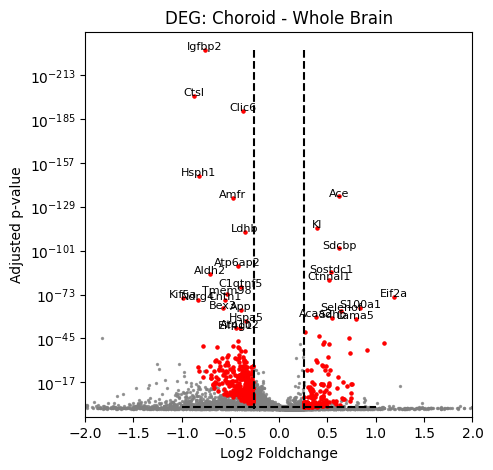

In [68]:
key = 'Choroid'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(df_filter[key][df_filter[key]['pvals_adj']< 1e-50]['names']):
    plt.text(df_filter[key][df_filter[key]['pvals_adj']< 1e-50]['logfoldchanges'][idx],
    df_filter[key][df_filter[key]['pvals_adj']< 1e-50]['pvals_adj'][idx]*0.55, str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
plt.ylim(0,100000)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"DEG: {key} - Whole Brain")
# plt.savefig(f'Gallery/{today}/volcano_plot_{key}.svg')

In [ ]:
df_filter[key].index = df_filter[key]['names']

## DEG all celltypes in one region

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt


directory_DEG = f'{dir_notebook}/analysis/circa-SD/foldchanges/celltype_in_region'
region_of_interest = 'HIPP'

df_all = pd.read_excel(f'{directory_DEG}/{region_of_interest}_all_celltypes_DEG.xlsx', sheet_name=None)

In [ ]:
df_expressed = {}
for key in df_all.keys():
    if "SD1" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][(df_all[key]['pct_nz_group']>0.1) & df_all[key]['mean_count']>= 0.01]
    df_all[key].index = df_all[key]['names']

In [ ]:
df_filter = {}
for key in df_all.keys():
    df_filter[key] = df_all[key][(df_all[key]['pvals_adj'] < 0.05)
                                 & (df_all[key]['pct_nz_group'] > 0)
                                 & (df_all[key]['pct_nz_reference'] > 0)
                                 & (abs(df_all[key]['logfoldchanges']) > 0.26)
                                 & (df_all[key]['mean_count'] >= 0.01)
                                 ]

In [ ]:
df_deg_quant = []
expressed = [len(df_expressed[key]) for key in df_expressed.keys()]
deg_quant = [len(df_filter[key]) for key in df_filter.keys()]
deg_up = [len(df_filter[key][df_filter[key]['logfoldchanges'] > 0]) for key in df_filter.keys()]
deg_down = [len(df_filter[key][df_filter[key]['logfoldchanges'] < 0]) for key in df_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Celltype' : df_filter.keys(),
                                    'Expressed' : expressed,
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Celltype']
df_deg_quant = df_deg_quant[df_deg_quant["nb_DEG"] >= 5]
df_deg_quant.sort_values(by='nb_DEG', ascending = False)


In [ ]:
key = 'Astro TE'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=df_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')
plt.scatter(x=df_all[key]['logfoldchanges'], y = df_all[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= df_filter[key]['logfoldchanges'], y=df_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')

for idx, gene in enumerate(df_filter[key][df_filter[key]['pvals_adj']<0.0000000000001]['names']):
    plt.text(df_filter[key][df_filter[key]['pvals_adj']<0.0000000000001]['logfoldchanges'][idx], df_filter[key][df_filter[key]['pvals_adj']<0.0000000000001]['pvals_adj'][idx], str(gene), color = 'black', fontsize = 8, ha= 'center')

plt.yscale('log')
plt.xlim(-2,2)
plt.ylim(0,0)
plt.gca().invert_yaxis()
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.title(f"DEG: {key} - {region_of_interest}")
plt.savefig(f'Gallery/{today}/volcano_plot_{key}_{region_of_interest}.svg', dpi= 300)

## DEG celltype in diff regions

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

directory_DEG = '../notebook/analysis/circa-SD/foldchanges/celltype_in_region/'
all_regions = os.listdir(directory_DEG)

In [ ]:
all_regions =  [region for region in all_regions if region.split('_')[-1] == 'DEG.xlsx' ]
# all_regions.remove('MEA_all_celltypes_DEG.xlsx')
all_regions

In [ ]:
cell_type_inregion = "Microglia"
celltype_inregion_DEG = {}
for file in all_regions:
    region = file.split("_")[0]
    print(region)
    df = pd.read_excel(f'{directory_DEG}{file}', sheet_name= None)
    celltype_inregion_DEG[region] = df[cell_type_inregion]

In [ ]:
celltype_inregion_DEG = {key:val for key, val in celltype_inregion_DEG.items() if len(val)  > 1}

In [ ]:
for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG[key] = celltype_inregion_DEG[key][celltype_inregion_DEG[key]['group'] == 'SD1']
    celltype_inregion_DEG[key].index = celltype_inregion_DEG[key]['names']

celltype_inregion_DEG_filter = {}

for key in celltype_inregion_DEG.keys():
    celltype_inregion_DEG_filter[key] = celltype_inregion_DEG[key][(celltype_inregion_DEG[key]['pvals_adj'] < 0.05)
                                        #    & (celltype_inregion_DEG[key]['pct_nz_group'] > 0.05)
                                           & (abs(celltype_inregion_DEG[key]['logfoldchanges']) > 0.26)
                                           & (celltype_inregion_DEG[key]['mean_count'] > 0.01)
                                           ]

In [ ]:
deg_quant = [len(celltype_inregion_DEG_filter[key]) for key in celltype_inregion_DEG_filter.keys()]
deg_up = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]) for key in celltype_inregion_DEG_filter.keys()]
deg_down = [len(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]) for key in celltype_inregion_DEG_filter.keys()]

df_deg_quant = pd.DataFrame(data = {'Region' : celltype_inregion_DEG_filter.keys(),
                                    'nb_DEG' : deg_quant,
                                    'Upregulated': deg_up,
                                    'Downregulated': deg_down})

df_deg_quant.index = df_deg_quant['Region']
df_deg_quant.drop(['VLMC','Ependymal', "Choroid"], axis=0, inplace=True)
df_deg_quant = df_deg_quant[df_deg_quant['nb_DEG'] > 10]

In [ ]:
plt.figure(figsize=(3,3))
df_deg_quant.sort_values(by='nb_DEG', inplace=True)
plt.barh(y = df_deg_quant['Region'], width=df_deg_quant['Upregulated'], edgecolor ='black')
plt.barh(y = df_deg_quant['Region'], width=-df_deg_quant['Downregulated'], edgecolor ='black')
plt.vlines(x=0, ymin=-1,ymax=len(df_deg_quant), color = 'black', linestyles='dashed')
plt.ylim(-0.5, len(df_deg_quant)-0.5)
plt.title(f'DEG: {cell_type_inregion} in different regions')

In [ ]:
celltype_inregion_DEG_filter['SCH'].sort_values(by="logfoldchanges")

In [ ]:
key = 'WM'

plt.figure(figsize=(5,5))
plt.vlines(x=(-0.26,0.26), ymin=celltype_inregion_DEG_filter[key]['pvals_adj'].min(), ymax=1, color = "black", linestyles='dashed')
plt.hlines(y=0.05, xmin=-1, xmax=1, color = "black", linestyles='dashed')

plt.scatter(x=celltype_inregion_DEG[key]['logfoldchanges'], y = celltype_inregion_DEG[key]['pvals_adj'], s=2, alpha= 0.75, color = "grey", edgecolors=None)
plt.scatter(x= celltype_inregion_DEG_filter[key]['logfoldchanges'], y=celltype_inregion_DEG_filter[key]['pvals_adj'], s=5, alpha=1, color = 'red')
for idx, gene in enumerate(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['names']):
    plt.text(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['logfoldchanges'][idx],
             celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['pvals_adj']< 1e-12]['pvals_adj'][idx]*0.55,
             str(gene), color = 'black', fontsize = 8, ha= 'center')
plt.yscale('log')
plt.xlim(-2,2)
# plt.ylim(0,50)
plt.gca().invert_yaxis()
plt.title(f'DEG: {cell_type_inregion} in {key}')
plt.xlabel('Log2 Foldchange')
plt.ylabel('Adjusted p-value')
plt.savefig(f'Gallery/{today}/volcano_plot_{cell_type_inregion}_in_{key}.svg')

In [ ]:
list_genes = set()
for key in celltype_inregion_DEG_filter.keys():
    print(key)
    temp = set(celltype_inregion_DEG_filter[key]['names'].values)
    list_genes.update(temp)
len(list_genes)


In [ ]:
temp = set("Sod1")

In [ ]:
up_reg = celltype_inregion_DEG_filter['STR'][celltype_inregion_DEG_filter['STR']['logfoldchanges'] > 0.26]['names'].values
down_reg = celltype_inregion_DEG_filter['STR'][celltype_inregion_DEG_filter['STR']['logfoldchanges'] < 0.26]['names'].values

In [ ]:
up_reg

## Tests

In [ ]:
dict_all_cycling['SMC']['NS_cyc'].keys()

In [ ]:
NS_only = set()
SD_only = set()
common_only = set()

for celltype in dict_all_cycling.keys():
    NS_cyc = set(dict_all_cycling[celltype]['NS_cyc_filter']["CycID"])
    SD_cyc = set(dict_all_cycling[celltype]['SD_cyc_filter']["CycID"])
    common_cyc = NS_cyc.intersection(SD_cyc)
    common_only.update(common_cyc)
    NS_temp = NS_cyc.difference(common_cyc)
    NS_only.update(NS_temp)
    SD_temp = SD_cyc.difference(common_cyc)
    SD_only.update(SD_temp)
    


In [ ]:
celltype = "Microglia"

NS_cyc = dict_all_cycling[celltype]['NS_cyc_filter']["CycID"]
SD_cyc = dict_all_cycling[celltype]['SD_cyc_filter']["CycID"]

In [ ]:
print(*NS_cyc.index)

## GO analysis

### Pre-process

In [53]:
## Download ontologies from http://geneontology.org/ontology/go-basic.obo
## Download associations from ftp://ftp.ncbi.nlm.nih.gov/gene/DATA/gene2go.gz

from goatools.base import download_go_basic_obo
from goatools.base import download_ncbi_associations
from goatools.obo_parser import GODag
from goatools.anno.genetogo_reader import Gene2GoReader

# obo_fname = download_go_basic_obo()
fin_gene2go = download_ncbi_associations()
obodag = GODag("go-basic.obo")



  EXISTS: gene2go
go-basic.obo: fmt(1.2) rel(2025-07-22) 43,230 Terms


In [54]:
# Read NCBI's gene2go. Store annotations in a list of namedtuples

objanno = Gene2GoReader(fin_gene2go, taxids=[10090])
ns2assoc = objanno.get_ns2assc()

for nspc, id2gos in ns2assoc.items():
    print("{NS} {N:,} annotated mouse genes".format(NS=nspc, N=len(id2gos)))

HMS:0:01:39.157272 618,204 annotations, 26,443 genes, 19,022 GOs, 1 taxids READ: gene2go 
MF 19,140 annotated mouse genes
CC 22,723 annotated mouse genes
BP 21,889 annotated mouse genes


In [55]:
from module.genes_ncbi_mouse_proteincoding import GENEID2NT as GeneID2nt_mouse

print(len(GeneID2nt_mouse))

26326


In [56]:
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction method




Load BP Ontology Enrichment Analysis ...
 71% 18,622 of 26,326 population items found in association

Load CC Ontology Enrichment Analysis ...
 74% 19,591 of 26,326 population items found in association

Load MF Ontology Enrichment Analysis ...
 67% 17,738 of 26,326 population items found in association


In [57]:
## Get all the go items including those appears multiple times

GO_items = []

temp = goeaobj.ns2objgoea['BP'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['CC'].assoc
for item in temp:
    GO_items += temp[item]
    

temp = goeaobj.ns2objgoea['MF'].assoc
for item in temp:
    GO_items += temp[item]

In [58]:
## Build mapping dictionaries between gene id and gene symbols

id_mapper = {}

for key_2 in GeneID2nt_mouse:
    id_mapper[GeneID2nt_mouse[key_2].Symbol] = GeneID2nt_mouse[key_2].GeneID
    
rev_mapper = {v: k for k, v in id_mapper.items()} 

In [59]:
import numpy as np

def go_analysis(gene_list):
    
    mapped_gene = []

    for gene in gene_list:
        try:
            mapped_gene.append(id_mapper[gene])
        except:
            pass 
    
    goea_results_all = goeaobj.run_study(mapped_gene)  
    
    goea_results_sig = [r for r in goea_results_all if r.p_fdr_bh<0.05]
    
    
    df_go = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

    df_go = df_go[df_go.n_genes > 1]
    df_go['LogP'] = -np.log10(df_go['p'])
    return df_go

### Process

In [60]:
key = 'Choroid'

In [ ]:
target_genes_up = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(celltype_inregion_DEG_filter[key][celltype_inregion_DEG_filter[key]['logfoldchanges'] < 0]['names'])

In [61]:
target_genes_up = list(df_filter[key][df_filter[key]['logfoldchanges'] > 0]['names'])
target_genes_down = list(df_filter[key][df_filter[key]['logfoldchanges'] < 0]['names'])

In [ ]:
print(target_genes_up)

In [62]:
target_genes_up = [id_mapper[gene] for gene in target_genes_up if gene in id_mapper]
target_genes_down = [id_mapper[gene] for gene in target_genes_down if gene in id_mapper]



goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.05, # default significance cut-off
        methods = ['fdr_bh']) # defult multipletest correction methodgoea_results_all = goeaobj.run_study()

goea_results_up = goeaobj.run_study(target_genes_up)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_up = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_down = goeaobj.run_study(target_genes_down)
goea_results_down_sig = [r for r in goea_results_down if r.p_fdr_bh<0.01]

df_go_down = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_down_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

                        


Load BP Ontology Enrichment Analysis ...
 71% 18,622 of 26,326 population items found in association

Load CC Ontology Enrichment Analysis ...
 74% 19,591 of 26,326 population items found in association

Load MF Ontology Enrichment Analysis ...
 67% 17,738 of 26,326 population items found in association

Runing BP Ontology Analysis: current study set of 163 IDs.
 99%    162 of    163 study items found in association
100%    163 of    163 study items found in population(26326)
Calculating 12,381 uncorrected p-values using fisher_scipy_stats
  12,381 terms are associated with 18,622 of 26,326 population items
   1,512 terms are associated with    162 of    163 study items
  METHOD fdr_bh:
      38 GO terms found significant (< 0.05=alpha) ( 38 enriched +   0 purified): statsmodels fdr_bh
      94 study items associated with significant GO IDs (enriched)
       0 study items associated with significant GO IDs (purified)

Runing CC Ontology Analysis: current study set of 163 IDs.
 99%    

In [ ]:
### Alternative Cycling genes
target_genes_NS = NS_cyc
target_genes_NS = [id_mapper[gene] for gene in target_genes_NS if gene in id_mapper]

target_genes_SD = SD_cyc
target_genes_SD = [id_mapper[gene] for gene in target_genes_SD if gene in id_mapper]

goeaobj = GOEnrichmentStudyNS(
        GeneID2nt_mouse.keys(), # List of human protein-coding genes
        ns2assoc, # geneid/GO associations
        obodag, # Ontologies
        propagate_counts = False,
        alpha = 0.1, # default significance cut-off
        methods = ['fdr_bh']) # default multiple test correction method

goea_results_up = goeaobj.run_study(target_genes_NS)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_NS = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

goea_results_up = goeaobj.run_study(target_genes_SD)
goea_results_up_sig = [r for r in goea_results_up if r.p_fdr_bh<0.01]

df_go_SD = pd.DataFrame(list(map(lambda x: [x.GO, x.goterm.name, x.goterm.namespace, x.p_uncorrected, x.p_fdr_bh,\
                         x.ratio_in_study[0], x.ratio_in_study[1], GO_items.count(x.GO), list(map(lambda y: rev_mapper[y], 
                         x.study_items))], goea_results_up_sig)), 
                         columns = ['GO', 'term', 'class', 'p', 'p_corr', 'n_genes','n_study', 'n_go', 'study_genes'])

df_go_NS.head(15), df_go_SD.head(15)

### GO plot

In [63]:
df_go_down.head(5)
len(df_go_up)

38

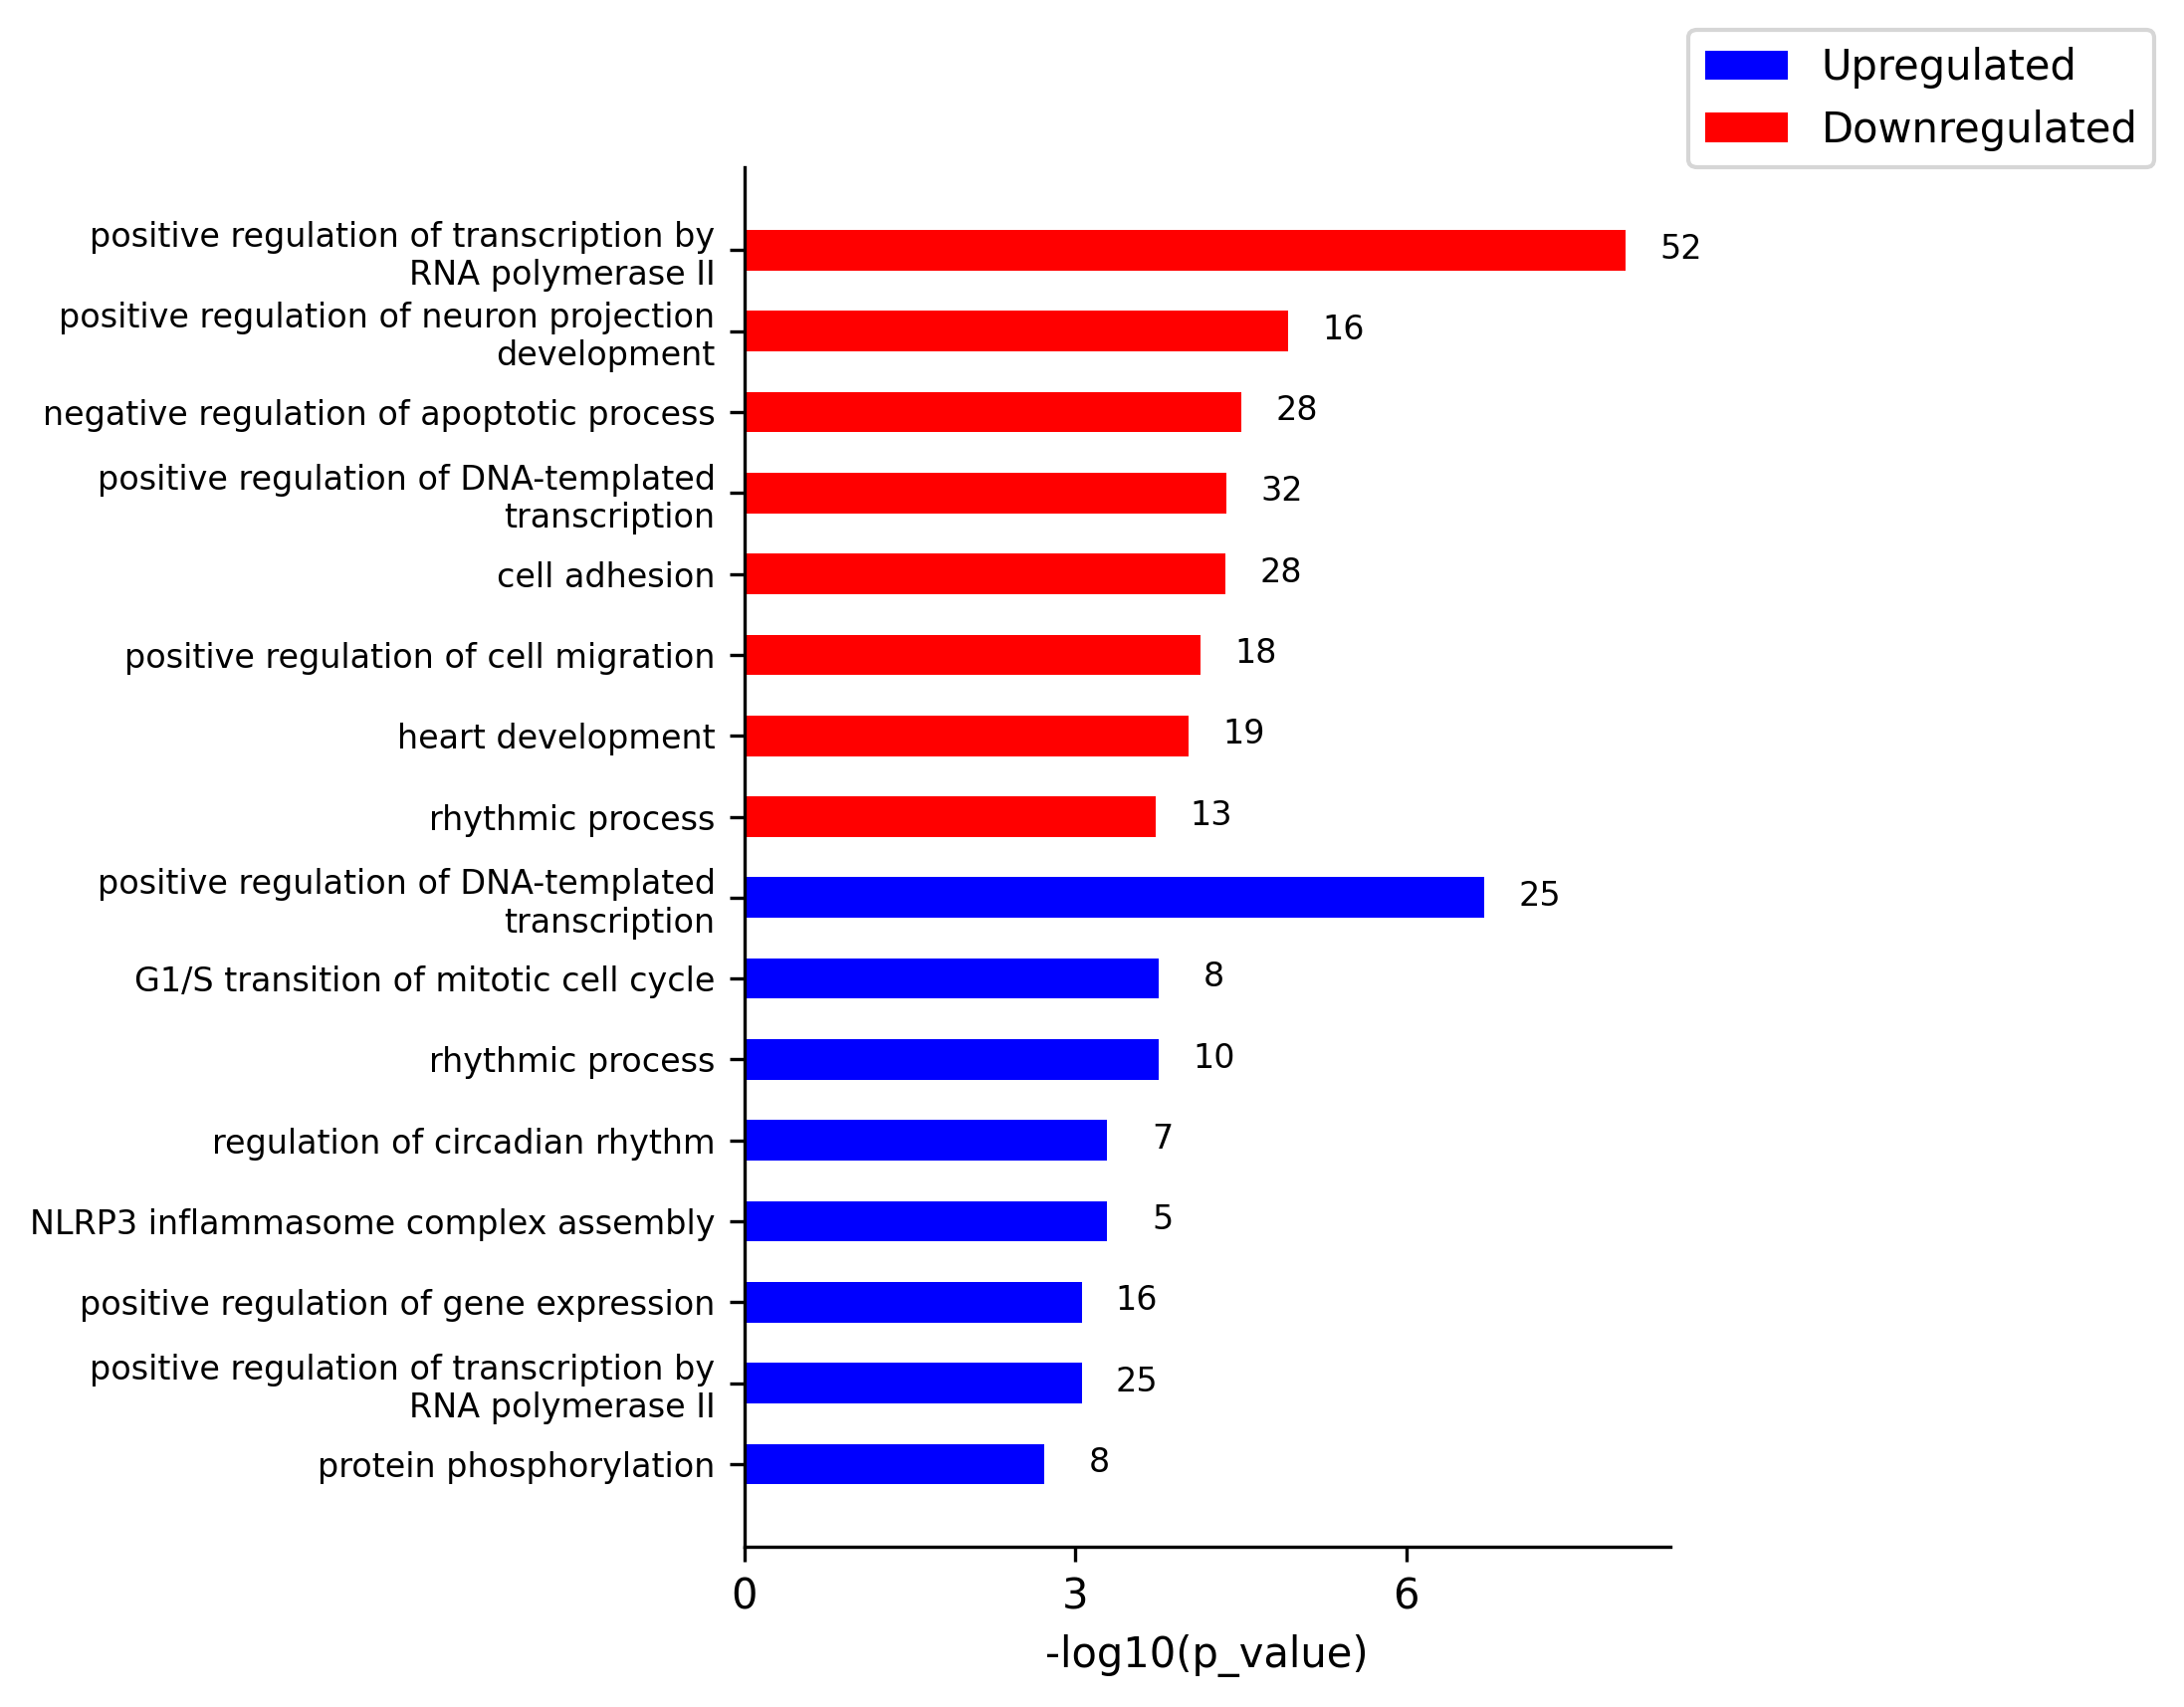

In [69]:
import matplotlib.pyplot as plt
import numpy as np
import textwrap

plt.figure(figsize=(4,6),dpi=300)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.rcParams["font.size"] = 10

if min(len(df_go_up), len(df_go_down)) > 7:
    n_g = 8
else:
    n_g = min(len(df_go_up), len(df_go_down))

up_labels = [s for s in df_go_up['term'][0:n_g]][::-1]
up_ngenes = [s for s in df_go_up['n_genes'][0:n_g]][::-1]
up_pvalues = [-np.log10(p) for p in df_go_up['p_corr'][0:n_g]][::-1]
up_ycor = [0.1*n for n in range(1,len(up_labels)+1)]

down_labels = [s for s in df_go_down['term'][0:n_g]][::-1]
down_ngenes = [s for s in df_go_down['n_genes'][0:n_g]][::-1]
down_pvalues = [-np.log10(p) for p in df_go_down['p_corr'][0:n_g]][::-1]
down_ycor = [0.1*n for n in range(len(down_labels)+1,len(down_labels)+len(up_labels)+1)]

#print(len(y_cor),len(labels),len(p_values))

plt.barh(up_ycor,up_pvalues,height=0.05, color = 'blue', label = 'Upregulated')

plt.barh(down_ycor,down_pvalues,height=0.05, color = 'red', label = 'Downregulated')

plt.yticks(up_ycor+down_ycor,[textwrap.fill(e,40) for e in up_labels+down_labels],fontsize=8)

for x,gene in enumerate(up_ngenes):
    plt.text(up_pvalues[x] + 0.5, up_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

for x,gene in enumerate(down_ngenes):
    plt.text(down_pvalues[x] + 0.5, down_ycor[x]-0.01, gene, color = 'black', fontsize = 8, ha= 'center')

#plt.yticks()
plt.xticks([0,3.0,6.0])
plt.xlabel('-log10(p_value)')
# plt.ylim(0,n_g)

plt.savefig(f'Gallery/{today}/GO_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')

# plt.savefig(f'Gallery/{today}/GO_{region_of_interest}_{key}.svg',format = "svg", dpi=300,transparent = True, bbox_inches='tight')
plt.legend(markerscale=20, bbox_to_anchor=(1.02, 1), loc='lower left', borderaxespad=0)
plt.show()

In [70]:
df_go_down

,GO,term,class,p,p_corr,n_genes,n_study,n_go,study_genes
0,GO:0045944,positive regulation of transcription by RNA po...,biological_process,8.222381e-13,1.018013e-08,52,345,1313,"[Men1, Nrf1, Ddit3, Hsph1, Anxa2, Cited2, Tlr2..."
1,GO:0010976,positive regulation of neuron projection devel...,biological_process,1.903810e-09,1.178553e-05,16,345,181,"[Dbn1, Ndrg4, Mapt, Acsl6, Stmn2, Cntn1, Prkci..."
2,GO:0043066,negative regulation of apoptotic process,biological_process,7.503901e-09,3.096860e-05,28,345,620,"[Pdpn, Itch, Traf2, Adora1, Cited2, Aldh2, Gst..."
3,GO:0045893,positive regulation of DNA-templated transcrip...,biological_process,1.370545e-08,4.242181e-05,32,345,778,"[Men1, Kpna2, Trim27, Ddit3, Rhog, Cited2, Chd..."
4,GO:0007155,cell adhesion,biological_process,1.743250e-08,4.316636e-05,28,345,622,"[Lama2, Pdpn, Cntn1, Tln1, Anxa2, Col18a1, Nid..."
5,GO:0030335,positive regulation of cell migration,biological_process,3.540758e-08,7.306355e-05,18,345,279,"[Thbs1, Podxl, Pdpn, Rack1, Grn, Rictor, Hspa5..."
6,GO:0007507,heart development,biological_process,5.258374e-08,9.300561e-05,19,345,321,"[Smyd2, Gja1, Grk2, Cited2, Gjc1, Ankrd11, Pdg..."
7,GO:0048511,rhythmic process,biological_process,1.237344e-07,1.869193e-04,13,345,154,"[Per1, Per2, Fbxw7, Ppara, Rack1, Sin3a, Kdm2a..."
8,GO:0016477,cell migration,biological_process,1.358754e-07,1.869193e-04,18,345,308,"[Thbs1, Vtn, Ntn4, Podxl, Pdpn, Prkci, Pxn, Sd..."
9,GO:0042752,regulation of circadian rhythm,biological_process,2.251304e-07,2.424042e-04,9,345,67,"[Per1, Per2, Fbxw7, Ppara, Kdm2a, Ccar2, Tardb..."


# Upset plot

In [ ]:
from upsetplot import plot
from upsetplot import from_contents


In [ ]:
test_dict = {"Microglia": df_filter['Microglia']['names'].values,
             "Astro TE": df_filter['Astro TE']['names'].values,
             "Oligodendrocytes" : df_filter['Oligodendrocyte']['names'].values}

In [ ]:
celltype_inregion_DEG_filter.keys()

In [ ]:
from upsetplot import from_contents

common = from_contents(test_dict)

plot(common)  

# Circascore v2

In [ ]:
geno_dict = {"WT":0,
             "APP":1}
df_circa_temp['Genotype_num'] = df_circa_temp['Genotype'].map(geno_dict)

In [ ]:
import seaborn as sns
df_circa_temp['Genotype_num'] = df_circa_temp['Genotype_num'].astype(str)
num_clusters = len(df_circa_temp['Genotype_num'].astype(int).unique())
cmap_ = "viridis"
palette = sns.color_palette(cmap_, n_colors=num_clusters)
df_circa_temp['leiden_colors'] = df_circa_temp['Genotype_num'].astype(int).apply(lambda x: palette[x])


In [ ]:
import seaborn  as sns

sns.clustermap(df_plot, cmap = 'inferno', vmin=0,vmax=1, z_score=1,
                col_cluster=True,row_cluster=True, cbar = True, cbar_pos=None,figsize=(20, 40),
                dendrogram_ratio= 0.05,
                # row_colors=df_circa_temp['leiden_colors'],
                )

## run

In [ ]:
import pickle

with open(f"data/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)


In [ ]:
from module.misc import genes_list

clockgeneslist = genes_list('clock')

list_of_cells = dict_all_cycling.keys()

In [24]:
### Create dataframe for normalized gene expression

norm_exp_NS = {}
norm_exp_SF = {}

for gene in clockgeneslist:
    temp_NS = pd.DataFrame(index=list_of_cells)
    temp_SF = pd.DataFrame(index=list_of_cells)

    temp_NS['mean_count'] = 0.0
    temp_SF['mean_count'] = 0.0

    for cell in list_of_cells:
        temp_NS.loc[cell, 'mean_count'] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=='circa4'].loc[gene,'mean_count']
        temp_SF.loc[cell, 'mean_count'] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=='SD1'].loc[gene,'mean_count']
    
    norm_exp_NS[gene] = temp_NS
    norm_exp_SF[gene] = temp_SF

for gene in clockgeneslist:
    norm_exp_NS[gene]['normalized_count'] = norm_exp_NS[gene]['mean_count'] / max(norm_exp_NS[gene]['mean_count'])
    norm_exp_SF[gene]['normalized_count'] = norm_exp_SF[gene]['mean_count'] / max(norm_exp_SF[gene]['mean_count'])



In [ ]:
circascore = pd.DataFrame(index=list_of_cells)
circascore['circascore_NS'] = 0.0
circascore['circascore_SF'] = 0.0

for cell in list_of_cells:
    temp_comb_NS = 0.0
    temp_comb_SF = 0.0

    for gene in clockgeneslist:
        prct_group = dict_all_cycling['ABC']['DEG'][dict_all_cycling['ABC']['DEG']['group']=='circa4'].loc[gene, 'pct_nz_group']
        norm_mean_exp = norm_exp_NS[gene]['normalized_count'][cell]

        temp = (1+ prct_group) * (1 + norm_mean_exp)

        if len(set([gene]).intersection(set(dict_all_cycling[cell]['NS_cyc_filter']['CycID'].values))) == 1:
            temp = temp * 2 ### Factor depending on the number of celltype having this gene cycling ? 
        else:
            temp = temp
    
        temp_comb_NS += temp
    
    circascore.loc[cell, 'circascore_NS'] = temp_comb_NS.astype(float)

    for gene in clockgeneslist:
        prct_group = dict_all_cycling['ABC']['DEG'][dict_all_cycling['ABC']['DEG']['group']=='SD1'].loc[gene, 'pct_nz_group']
        norm_mean_exp = norm_exp_SF[gene]['normalized_count'][cell]

        temp = (1 + prct_group) * (1 + norm_mean_exp)

        if len(set([gene]).intersection(set(dict_all_cycling[cell]['SD_cyc_filter']['CycID'].values))) == 1:
            temp = temp * 2 ### Factor depending on the number of celltype having this gene cycling ? 
        else:
            temp = temp
    
        temp_comb_SF += temp
    
    circascore.loc[cell, 'circascore_SF'] = temp_comb_SF.astype(float)


<BarContainer object of 36 artists>

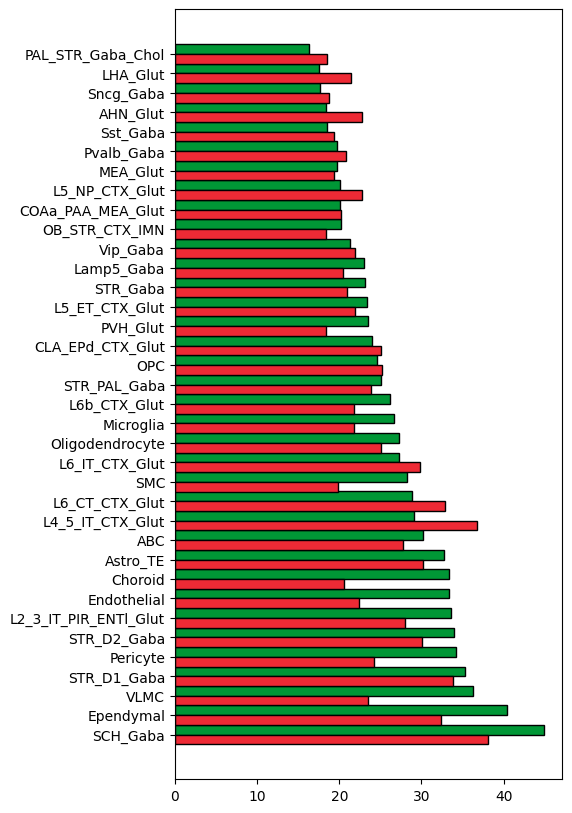

In [34]:
circascore.sort_values(by='circascore_NS', ascending = False, inplace = True)

plt.figure(figsize = (5,10))
plt.barh(circascore.index, circascore['circascore_NS'], height=0.5, edgecolor ='black', align = "edge", label = "NS" )
plt.barh(circascore.index, circascore['circascore_SF'], height=-0.5, edgecolor ='black', align = "edge", label = 'SF' )

# plt.xscale('log')

In [48]:
circascore['Diff'] = circascore['circascore_SF'] - circascore['circascore_NS']

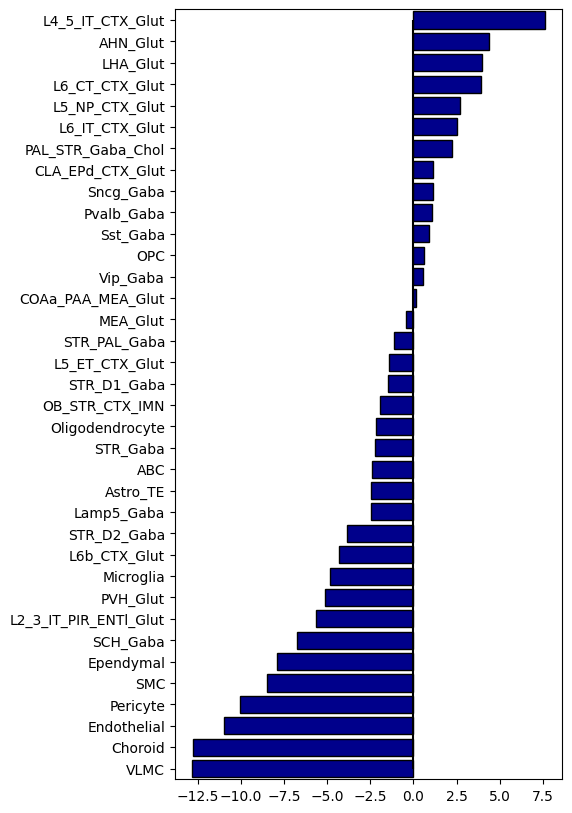

In [49]:
plt.figure(figsize = (5,10))

plt.barh(circascore.sort_values(by='Diff').index, circascore.sort_values(by='Diff')['Diff'], color= 'darkblue', edgecolor= 'black')
plt.ylim(-0.5, 35.5)
plt.vlines(x=0, ymin = 0, ymax = 35, color = 'black')

# Test

In [6]:
df_all = pd.read_excel(f'{dir_notebook}/analysis/circa-SD/foldchanges/celltype/DEG_celltype_no-filter.xlsx', sheet_name=None)
df_expressed = {}
for key in df_all.keys():
    if "circa4" in df_all[key]["group"].unique():
        df_all[key] = df_all[key][df_all[key]['group'] == 'SD1']
    df_expressed[key] = df_all[key][
            (df_all[key]['pct_nz_group']>0.05) &
          (df_all[key]['mean_count']>= 0.01)
          ]
    df_all[key].index = df_all[key]['names']

In [6]:
import pandas as pd
import pickle

df = pd.read_pickle('data/cycling_genes_database.pickle')


In [7]:
df_all[key].keys()

NameError: name 'df_all' is not defined

In [133]:
keys = df_all.keys()
temp_set = set()

for key in keys:
    temp = df_all[key][(df_all[key]['mean_count']>0.01)
                       & (df_all[key]['mean_count']>0.05)].sort_values(by="mean_count")['names'].values
    temp_set.update(temp)

In [134]:
len(temp_set)

3749

In [40]:
temp_set = list(temp_set)

In [44]:
temp_set = pd.DataFrame(temp_set)
temp_set.to_csv('data/temp_set_expressed_genes.csv')

In [88]:
4264/5006*100
# 742+4264


85.17778665601278

In [99]:
from module.misc import genes_list
panel_5k = genes_list('panel_5k')

In [53]:
panel = set(panel)
diff = temp_set.difference(panel)

In [56]:
len(diff)

TypeError: object of type 'NoneType' has no len()

In [57]:
panel.difference_update(temp_set)

In [59]:
len(panel)

742

In [87]:
not_exp = pd.DataFrame(panel)
not_exp.to_csv('data/not_exp.csv')

In [ ]:
df_all['Tanycyte'][(df_all['Tanycyte']['mean_count']>0.01)
                   & (df_all['Tanycyte']['pct_nz_group']>0.05)
                   & (df_all['Tanycyte']['group'] == "circa4")].shape

(2349, 9)

In [137]:
keys = df_all.keys()
ddf = pd.DataFrame(index=list(panel))
ddf['count_SF'] = 0
ddf['count_NS'] = 0

for gene in panel_5k:
    count_NS = 0
    count_SF = 0
    for key in keys:
        if len(df_all[key][(df_all[key]["names"]==gene)
                           & (df_all[key]["mean_count"]>0.01)
                           & (df_all[key]["group"]== 'circa4')
                           & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            count_NS +=1
        if len(df_all[key][(df_all[key]["names"]==gene)
                & (df_all[key]["mean_count"]>0.01)
                & (df_all[key]["group"]== 'SD1')
                & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            count_SF +=1
    ddf.loc[gene, "count_NS"] = count_NS
    ddf.loc[gene, "count_SF"] = count_SF

In [159]:
ddf['Diff'] = ddf['count_NS']- ddf['count_SF']

ddf.head(10),ddf.tail(10)

(        count_SF  count_NS  Diff
 Psmd11      40.0      12.0 -28.0
 Eif2s1      36.0      11.0 -25.0
 Alg13       42.0      19.0 -23.0
 Tctn1       30.0       8.0 -22.0
 Nup155      54.0      33.0 -21.0
 Zup1        50.0      30.0 -20.0
 Tyk2        34.0      16.0 -18.0
 Mxd4        60.0      43.0 -17.0
 Pde3b       34.0      17.0 -17.0
 Atm         44.0      27.0 -17.0,
           count_SF  count_NS  Diff
 Hspa1b        15.0      33.0  18.0
 Mtx1          18.0      37.0  19.0
 Ezr           18.0      38.0  20.0
 Acss1         36.0      56.0  20.0
 Aqp4          38.0      59.0  21.0
 Csf1r         22.0      44.0  22.0
 Nde1          21.0      44.0  23.0
 Nup62          4.0      28.0  24.0
 Slc9a3r1      32.0      57.0  25.0
 Daam2         21.0      51.0  30.0)

<BarContainer object of 5006 artists>

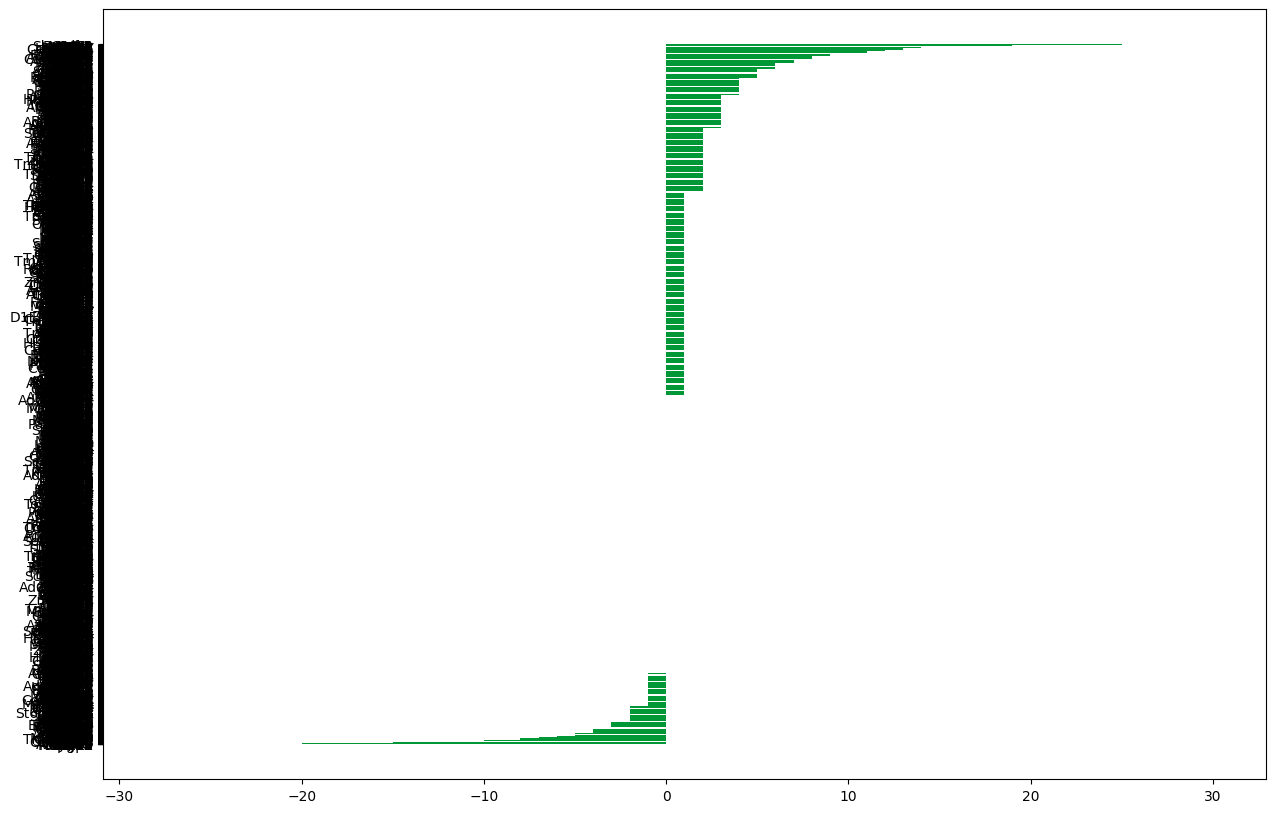

In [ ]:
# plt.scatter(x = ddf["count_NS"], y=ddf['count_SF'])
# plt.xlabel('NS')
# plt.ylabel('SF')
# for gene in ddf.index:
#     plt.text(x = ddf["count_NS"][gene], y=ddf['count_SF'][gene], s = gene)

# ddf.sort_values(by='count_SF', inplace = True)
# plt.figure(figsize=(15,10))
# plt.bar(x=ddf.index, height = ddf['count_NS'], label = "NS")
# plt.bar(x=ddf.index, height = ddf['count_SF'], label = "SF")
# plt.legend()

# ddf.sort_values(by='Diff', inplace = True)
# plt.figure(figsize=(15,10))
# plt.barh(y=ddf.index, width = ddf['Diff'], label = "Diff")

In [107]:
ddf_n0 = ddf[ddf['count'] != 0]
ddf_n0['count'].value_counts()

count
64.0    1263
1.0      281
63.0     188
2.0      156
62.0     121
3.0      117
4.0       99
61.0      97
60.0      83
7.0       78
5.0       77
58.0      73
6.0       72
59.0      68
57.0      59
10.0      51
8.0       46
9.0       45
54.0      43
56.0      42
53.0      41
55.0      39
11.0      37
48.0      37
18.0      36
51.0      36
12.0      34
46.0      28
14.0      26
15.0      26
49.0      26
40.0      25
43.0      25
16.0      24
52.0      24
17.0      23
21.0      23
20.0      21
19.0      21
26.0      20
44.0      20
25.0      20
22.0      20
50.0      20
13.0      19
32.0      19
30.0      18
24.0      18
41.0      18
38.0      18
23.0      17
33.0      17
31.0      17
29.0      16
42.0      16
47.0      16
35.0      14
37.0      14
27.0      13
34.0      13
39.0      13
28.0      11
45.0      10
36.0       9
Name: count, dtype: int64

In [115]:
dddf = pd.DataFrame(index = ddf[ddf['count'] == 1].index)
dddf['celltype'] = "0"

for gene in ddf[ddf['count'] == 1].index:
    for key in keys:
        if len(df_all[key][(df_all[key]["names"]==gene) & (df_all[key]["mean_count"]>0.01)
                        & (df_all[key]["pct_nz_group"] > 0.05)]) > 0:
            print(key)
            dddf.loc[gene,'celltype'] = key

Endothelial
SMC
ABC
Ependymal
Ependymal
MPO Glut
Microglia
OB STR CTX IMN
OB STR CTX IMN
MH Glut
OB STR CTX IMN
Microglia
PT Glut
Choroid
OB STR CTX IMN
OB STR CTX IMN
OB STR CTX IMN
SPA Glut
Microglia
OB STR CTX IMN
Microglia
Microglia
Microglia
MH Glut
OB STR CTX IMN
VLMC
TRS BAC Glut
OB STR CTX IMN
VLMC
Microglia
VLMC
Microglia
Microglia
L4 5 IT CTX Glut
Microglia
Microglia
OB STR CTX IMN
OB STR CTX IMN
OB STR CTX IMN
MEA Glut
Ependymal
OB STR CTX IMN
OB STR CTX IMN
OB STR CTX IMN
Ependymal
OB STR CTX IMN
SMC
LHA Glut
ABC
MH Glut
Choroid
VLMC
Ependymal
Choroid
Choroid
Choroid
Tanycyte
SMC
RT ZI Gaba
Choroid
MPO Glut
Choroid
Microglia
Tanycyte
Microglia
Microglia
Microglia
TRS BAC Glut
LSX Gaba
VLMC
Microglia
AD Glut
Ependymal
Sst Gaba
Ependymal
BST Glut
Ependymal
MPO Glut
OB STR CTX IMN
OB STR CTX IMN
Microglia
OB STR CTX IMN
OB STR CTX IMN
Choroid
L2 3 IT RSP Glut
ABC
Choroid
OB STR CTX IMN
Oligodendrocyte
ABC
OPC
SMC
SPA Glut
Choroid
PAL STR Gaba Chol
Ependymal
OB STR CTX IMN
Endo

In [116]:
dddf['celltype'].value_counts()

celltype
OB STR CTX IMN           46
Microglia                42
Ependymal                26
Choroid                  25
ABC                      22
VLMC                     11
SMC                      10
Tanycyte                  8
Oligodendrocyte           8
Endothelial               7
MH Glut                   7
STR D1 Gaba               5
OPC                       4
Pericyte                  4
RT ZI Gaba                4
PAL STR Gaba Chol         4
PVH Glut                  3
AD Glut                   3
TRS BAC Glut              3
PT Glut                   3
MPO Glut                  3
AV Glut                   2
Astro TE                  2
L5 NP CTX Glut            2
CA2 FC IG Glut            2
L2 3 IT PIR ENTl Glut     2
COAa PAA MEA Glut         2
BST Glut                  2
Sst Gaba                  2
SPA Glut                  2
AHN Glut                  1
MEA Glut                  1
L5 ET CTX Glut            1
BAC Glut                  1
STR PAL Gaba              1
DG Glut    

In [120]:
dddf.sort_values(by='celltype', inplace=True)
dddf

,celltype
Erbb2,ABC
Msln,ABC
Lmx1b,ABC
Nphs2,ABC
Pfkfb1,ABC
Piezo2,ABC
H19,ABC
Wnt16,ABC
Rabep2,ABC
Shisa3,ABC


In [85]:
df_all['PVH Glut'][df_all['PVH Glut']["names"]=="Opn3"]

,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,group,mean_count
names,,,,,,,,,
Opn3,Opn3,-4.457537,-0.680715,0.000008,0.000151,0.065260,0.092494,circa4,0.038959
Opn3,Opn3,4.457537,0.680715,0.000008,0.000151,0.092494,0.065260,SD1,0.038959


In [15]:
gene = "Camk2a"
keys = df_all.keys()
for key in keys:
    if len(df_all[key][(df_all[key]["names"]==gene)
                        & (df_all[key]["mean_count"]>0.01)
                        & (df_all[key]["group"] =="SD1")
                        & (df_all[key]["pct_nz_group"] > 0.05)]
                        # & (df_all[key]['pvals_adj']>0.05)
                        # & (df_all[key]['logfoldchanges'] > 0.26)
                        ) > 0:
        print(key)

Astro TE
BST Glut
Vip Gaba
Sst Gaba
PVH Glut
AHN Glut
LHA Glut
Oligodendrocyte
Endothelial
MEA Glut
Ependymal
VLMC
SCH Gaba
ABC
Lamp5 Gaba
STR PAL Gaba
L2 3 IT PIR ENTl Glut
CEA Gaba
LSX Gaba
STR Gaba
STR D2 Gaba
L6b CTX Glut
L4 5 IT CTX Glut
L6 IT CTX Glut
L5 ET CTX Glut
STR D1 Gaba
OPC
NLOT Glut
SMC
Pvalb Gaba
COAa PAA MEA Glut
Choroid
Pericyte
Microglia
CLA EPd CTX Glut
L6 CT CTX Glut
PAL STR Gaba Chol
PVT Glut
PT Glut
RE Glut
SPA Glut
OB STR CTX IMN
L5 NP CTX Glut
Sncg Gaba
RT ZI Gaba
CA3 Glut
TRS BAC Glut
BAC Glut
DG PIR Ex IMN
DG Glut
SMT Glut
AD Glut
AV Glut
CA2 FC IG Glut
MPO Glut
VM MD Glut
CM Glut
L2 3 IT RSP Glut
LD Glut
LH Glut
MH Glut
VP Glut
CA1 ProS Glut


In [232]:
keys = df_all.keys()
ddf = pd.DataFrame(index=list(keys))
ddf['count_SF'] = 0
ddf['count_NS'] = 0
ddf['Common'] = 0
ddf['Diff'] = 0
all_set = set()
diff_set = set()
common_set = set()

for key in keys:
    set_NS = set(df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'circa4')]['names'])
    
    count_NS = len(set_NS)

    set_SF = set(df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'SD1')]['names'])

    count_SF = len(set_SF)

    common_set = set_NS.intersection(set_SF)

    if len(set_NS) > len(set_SF):
        diff_set = set_NS.difference(set_SF)
    else:
        diff_set = set_SF.difference(set_NS)

    all_set.update(set_NS, set_SF)

    ddf.loc[key, "count_NS"] = count_NS
    ddf.loc[key, "count_SF"] = count_SF
    ddf.loc[key, "Common"] = len(common_set)
    ddf.loc[key, "Diff"] = len(diff_set)

In [247]:
len(df_all["Tanycyte"][(df_all["Tanycyte"]["mean_count"]>0.01) & (df_all["Tanycyte"]["group"]== 'circa4')]['names'])
# len(set_NS)

3143

In [234]:
df_all[key][(df_all[key]["mean_count"]>0.01) & (df_all[key]["group"]== 'SD1')]['names']

names
Gnaq          Gnaq
Rab3a        Rab3a
Vxn            Vxn
Grin1        Grin1
Sdhb          Sdhb
            ...   
Washc2      Washc2
Khsrp        Khsrp
Caprin1    Caprin1
Kif5a        Kif5a
Dbp            Dbp
Name: names, Length: 2742, dtype: object

In [235]:
# ddf['Diff'] =ddf['count_NS']-ddf['count_SF']
ddf#.sort_values(by='Common',ascending=False)

,count_SF,count_NS,Common,Diff
Astro TE,3186,3186,3186,0
BST Glut,3004,3004,3004,0
Vip Gaba,2993,2993,2993,0
Sst Gaba,2946,2946,2946,0
PVH Glut,3067,3067,3067,0
AHN Glut,3021,3021,3021,0
LHA Glut,3056,3056,3056,0
Oligodendrocyte,2893,2893,2893,0
Endothelial,3174,3174,3174,0
MEA Glut,3046,3046,3046,0


In [236]:
len(all_set)

4264

In [ ]:
dddf = pd.DataFrame()

In [ ]:
ddf_n0 = ddf[ddf['count'] != 0]
ddf_n0['count'].value_counts()

In [28]:
for key in df.keys():
    if len(df[key]['DEG_filter'][df[key]['DEG_filter']['names']=="Kif5a"]) > 0:
        print(key)

STR_Gaba
OB_STR_CTX_IMN
MEA_Glut
L5_NP_CTX_Glut
PAL_STR_Gaba_Chol
Vip_Gaba
VLMC
PVH_Glut
ABC
AHN_Glut
SCH_Gaba
L5_ET_CTX_Glut
Choroid
LHA_Glut
Ependymal
L6_CT_CTX_Glut
STR_D1_Gaba
L4_5_IT_CTX_Glut


## Clock genes binary

In [47]:
from module.misc import genes_list

clockgenes = genes_list('clock')

In [48]:
clockgenes.sort()
clockgenes

['Arntl',
 'Clock',
 'Cry1',
 'Cry2',
 'Npas2',
 'Nr1d1',
 'Per1',
 'Per2',
 'Per3',
 'Rora',
 'Rorb',
 'Rorc']

In [55]:
ddf = pd.DataFrame(index=cell_list_under)


for key in df.keys():
    
    for gene in clockgenes:
        temp = 0
        if len(df[key]['NS_cyc_filter']['CycID'][df[key]['NS_cyc_filter']['CycID']==gene]) > 0:
            temp += 0.5

        if len(df[key]['SD_cyc_filter']['CycID'][df[key]['SD_cyc_filter']['CycID']==gene]) > 0:
            temp += 1

        ddf.loc[key, gene] = temp
    


In [58]:
ddf.reindex(cell_list_under)

,Arntl,Clock,Cry1,Cry2,Npas2,Nr1d1,Per1,Per2,Per3,Rora,Rorb,Rorc
SMC,0.5,0.0,0.0,0.0,0.5,1.5,0.5,0.5,0.5,0.0,0.0,0.0
Sncg_Gaba,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
STR_Gaba,0.0,0.0,0.0,1.0,0.0,1.5,0.5,0.0,0.0,0.0,0.0,0.5
COAa_PAA_MEA_Glut,0.0,0.0,1.0,0.0,0.0,0.0,0.5,1.0,0.0,0.0,0.0,0.0
OB_STR_CTX_IMN,0.0,0.0,0.0,0.0,0.0,1.5,0.5,0.0,0.0,0.0,0.0,0.0
MEA_Glut,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.5,0.0,0.0,0.0
L5_NP_CTX_Glut,1.0,0.0,0.0,0.0,0.0,1.5,0.0,1.0,0.0,0.0,0.0,0.0
PAL_STR_Gaba_Chol,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
Vip_Gaba,0.0,0.0,0.5,0.0,0.0,1.0,0.5,0.0,0.0,1.0,1.0,0.0
Lamp5_Gaba,0.0,0.0,0.0,0.5,0.0,1.5,0.0,0.0,0.0,0.0,0.0,0.0


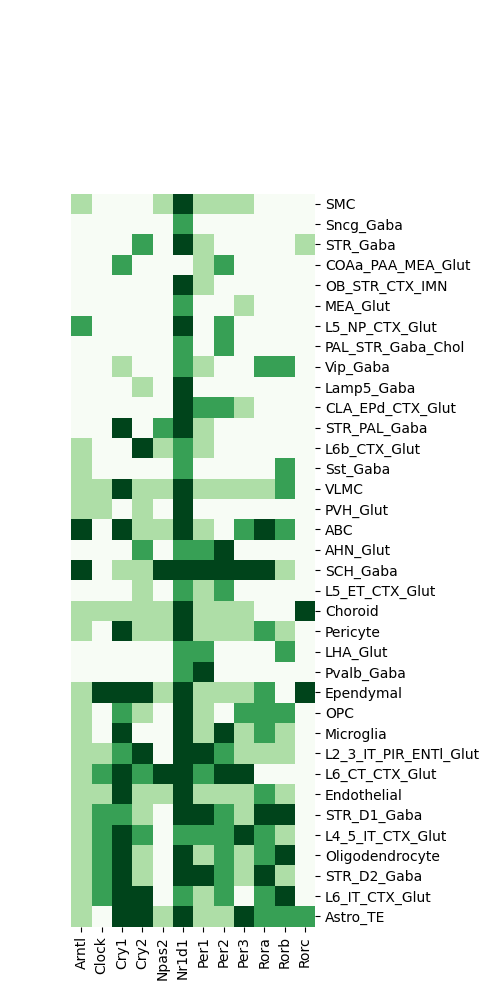

In [62]:
import seaborn as sns

sns.clustermap(ddf, cmap = 'Greens',
                col_cluster=False,row_cluster=False, cbar = False, cbar_pos=None,figsize=(5,10),
                )

In [34]:
len(df['SCH_Gaba']['SD_cyc_filter']['CycID'][df['SCH_Gaba']['SD_cyc_filter']['CycID']=='Rorc'])

0

# Unassigned Transcripts

In [16]:
import pandas as pd
from module.misc import genes_list



# df = pd.read_parquet('../data/circa4-IGM-ZT01/transcripts.parquet',
#                      columns=['feature_name', 'cell_id','qv'],
#                     #  filters = [('feature_name', '==', gene)]
#                      )

samples = ['3159-4','3161-3']

for sample in samples:
    df = pd.read_parquet(fr'D:\Xenium\{sample}\transcripts.parquet',
                        columns=['feature_name', 'cell_id','qv'],
                        filters = [('qv', '>=', 20)]
                        )
    
    df = df[(~df['feature_name'].str.contains('_'))]

    panel = genes_list('brain_panel')

    ddf_table = pd.DataFrame(index = panel)
    ddf_table['transcripts_0'] = 0
    ddf_table['transcripts_20'] = 0
    ddf_table['ratio_qv20'] = 0
    ddf_table['ratio_UNASSIGNED'] = 0


    # df['qv_modified'] = df.apply(lambda x: "20" if x['qv']>=20 else "0", axis = 1)
    df['unassigned'] = df.apply(lambda x: "UNASSIGNED" if x['cell_id']=="UNASSIGNED" else "ASSIGNED", axis = 1)

    # ddf = df.groupby(['qv_modified','feature_name'])['feature_name'].value_counts()

    ddf_assigned = df.groupby(['unassigned','feature_name'])['feature_name'].value_counts()

    # ddf_assigned_qv = df[df['qv_modified']=="20"].groupby(['unassigned','feature_name'])['feature_name'].value_counts()

    # ddf_table['transcripts_0'] = ddf["0"]
    # ddf_table['transcripts_20'] = ddf["20"]
    # ddf_table['total'] = ddf_table['transcripts_0'] + ddf_table['transcripts_20']
    # ddf_table['ratio_qv20'] = ddf["20"] / (ddf["0"]+ddf["20"])
    ddf_table['UNASSIGNED'] = ddf_assigned['UNASSIGNED']
    ddf_table['ASSIGNED'] = ddf_assigned['ASSIGNED']
    ddf_table['total'] = ddf_table['UNASSIGNED'] + ddf_table['ASSIGNED']
    ddf_table['ratio_UNASSIGNED'] = ddf_assigned['UNASSIGNED'] / ddf_table['total']
    # ddf_table['UNASSIGNED_qv20'] = ddf_assigned_qv['UNASSIGNED']
    # ddf_table['ASSIGNED_qv20'] = ddf_assigned_qv['ASSIGNED']
    # ddf_table['ratio_UNASSIGNED_qv20'] = ddf_assigned_qv['UNASSIGNED'] / (ddf_assigned_qv['UNASSIGNED'] + ddf_assigned_qv['ASSIGNED'])

    ddf_table.to_csv(f'data/{sample}_unassigned-ratio.csv')

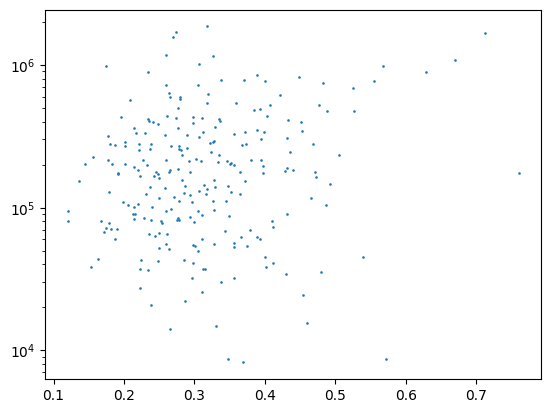

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x= ddf_table['ratio_UNASSIGNED'], y = ddf_table['ratio_UNASSIGNED_qv20'], s=0.75)
# for gene in ddf_table.index:
#     plt.text(x= ddf_table['ratio_UNASSIGNED'][gene], y = ddf_table['ratio_UNASSIGNED_qv20'][gene], s=gene)


Text(0, 0.5, 'ratio_unassigned_qv20')

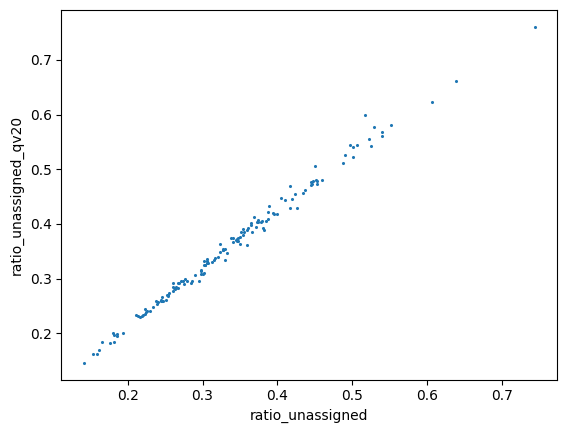

In [6]:
plt.scatter(x= ddf2['ratio_UNASSIGNED'], y = ddf2['ratio_UNASSIGNED_qv20'], s=1.5)
# for gene in ddf2.index:
#     plt.text(x= ddf2['ratio_UNASSIGNED'][gene], y = ddf2['ratio_UNASSIGNED_qv20'][gene], s=gene)
plt.xlabel('ratio_unassigned')
plt.ylabel('ratio_unassigned_qv20')

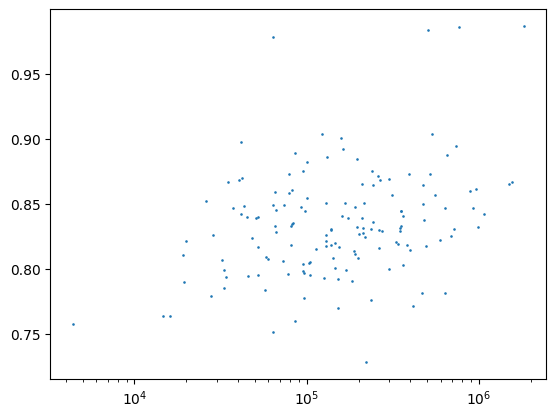

In [7]:
plt.scatter(x= ddf2['total'], y = ddf2['ratio_qv20'], s=0.75)
plt.xscale("log")

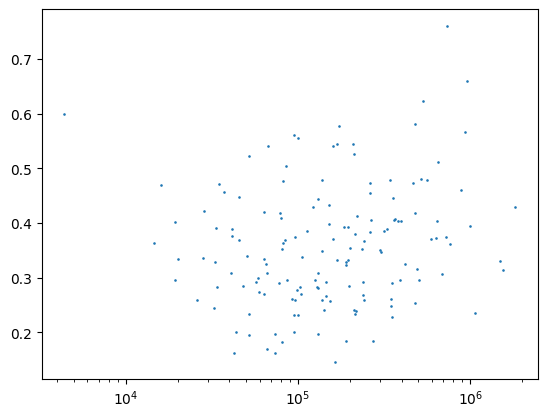

In [10]:
plt.scatter(x= ddf2['total'], y = ddf2['ratio_UNASSIGNED_qv20'], s=0.75)
plt.xscale("log")


# Ratio of cell expressing genes

In [ ]:
from module.misc import genes_list
import pandas as pd
import pickle

with open(f"{dir_notebook}/analysis/circa-SD/cycling_genes_database.pickle", "rb") as handle:
    dict_all_cycling = pickle.load(handle)

clock = genes_list('clock')

dfdf = pd.DataFrame(index=clock)

for cell in dict_all_cycling.keys():
    
    dfdf[cell] = dict_all_cycling[cell]['DEG'][dict_all_cycling[cell]['DEG']['group']=="circa4"]['pct_nz_group'][clock].values

In [8]:
dfdf.T.max()

Arntl    0.417191
Clock    0.196993
Cry1     0.137200
Cry2     0.566318
Nr1d1    0.484976
Per1     0.542608
Per2     0.306335
Per3     0.207274
Rora     0.572560
Rorb     0.607035
Rorc     0.141998
Npas2    0.500832
dtype: float64

<BarContainer object of 24 artists>

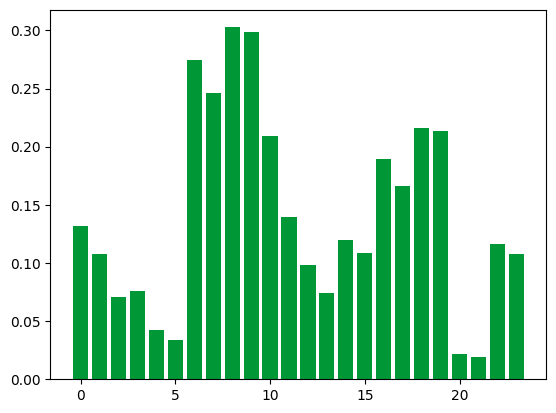

In [9]:
plt.bar(x=range(24), height = dict_all_cycling[cell]['DEG']['pct_nz_group'][clock].values)

Text(0.5, 1.0, 'Percentage of cells expressing CG')

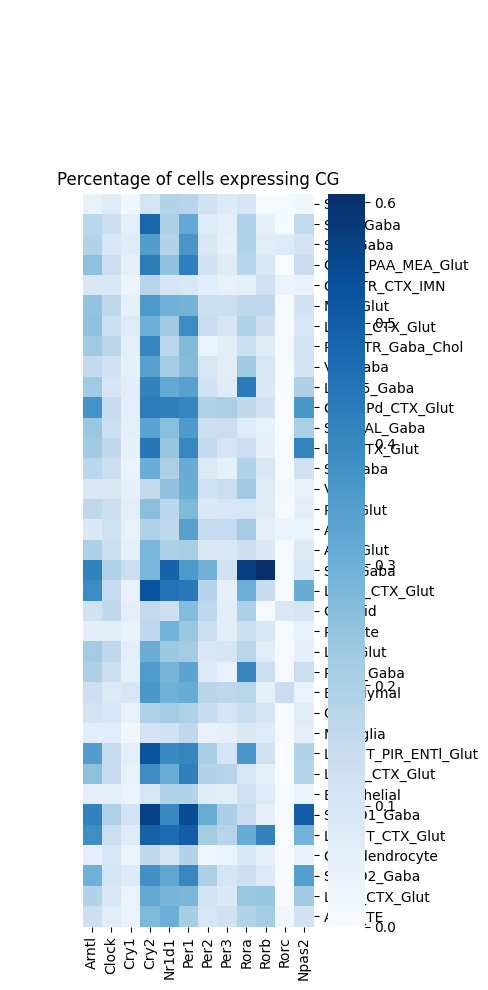

In [15]:
import seaborn as sns

sns.clustermap(dfdf.T, cmap = 'Blues', vmin= 0,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None,figsize=(5,10),
                )
plt.title('Percentage of cells expressing CG')
# plt.savefig(f'Gallery/{today}/NS_corr_cyclinggenes_ordernbcycgenes.svg',dpi=300)

In [6]:
df.head()

,A1cf,A2m,Aatf,Abca1,Abca13,Abca3,Abca4,Abca7,Abca8a,Abca8b,...,ZT,run,cell_type_final,region_automap_name,cell_class,circascore,x_centroid,y_centroid,Neurotransmitter,celltype_number
circa4-IGM-ZT01_aaaadmjm-1,0.0,0.0,0.0,0.0,0.0,0.525810,0.0,0.000000,0.0,0.000000,...,ZT01,circa4,Astro TE,AMY,Glial,5,3182.524170,1087.921265,Non-neuronal,61_Astro TE
circa4-IGM-ZT01_aaaahego-1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,ZT01,circa4,BST Glut,LHA,Neuronal,0,3867.802734,1032.575439,Glutamate,43_BST Glut
circa4-IGM-ZT01_aaaahemi-1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000000,...,ZT01,circa4,Vip Gaba,VLMC,Neuronal,1,3743.745850,867.053101,Gaba,21_Vip Gaba
circa4-IGM-ZT01_aaaannbb-1,0.0,0.0,0.0,0.0,0.0,0.350938,0.0,0.350938,0.0,0.350938,...,ZT01,circa4,Sst Gaba,AMY,Neuronal,3,3272.905518,1030.833008,Gaba,23_Sst Gaba
circa4-IGM-ZT01_aaabcllp-1,0.0,0.0,0.0,0.0,0.0,0.644081,0.0,0.000000,0.0,0.000000,...,ZT01,circa4,PVH Glut,WM,Neuronal,3,3995.378662,1026.414307,Glutamate,48_PVH Glut
